In [4]:
# Import all datasets for sit to stand

import pandas as pd
from data_collector import get_sit_to_stand_paths, get_sit_to_stand_challenge_paths, get_water_task_paths, get_water_task_challenge_paths, get_step_count_paths, get_step_count_challenge_paths
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

task = 'water'
if task == 'sit2stand':
    paths_standard = get_sit_to_stand_paths()
    paths_challenge = get_sit_to_stand_challenge_paths()
elif task == 'water':
    paths_standard = get_water_task_paths()
    paths_challenge = get_water_task_challenge_paths()
elif task == 'step_count':
    paths_standard = get_step_count_paths()
    paths_challenge = get_step_count_challenge_paths()

# Sort the paths by path.split('/')[-2]
paths_standard.sort(key=lambda x: x.split('/')[-2])
paths_challenge.sort(key=lambda x: x.split('/')[-2])

print("Standard paths:")
for path in paths_standard:
    print(path.split('/')[-2])

print("Challenge paths:")
for path in paths_challenge:
    print(path.split('/')[-2])


dfs_stand = [pd.read_csv(path) for path in paths_standard]
dfs_stand_challenge = [pd.read_csv(path) for path in paths_challenge]

if task=='step_count':
    # rename column from acceleration_m/s²_x to 'freeAcceleration_m/s²_x' for x y and z
    dfs_stand = [df.rename(columns={'acceleration_m/s²_x': 'freeAcceleration_m/s²_x', 'acceleration_m/s²_y': 'freeAcceleration_m/s²_y', 'acceleration_m/s²_z': 'freeAcceleration_m/s²_z'}) for df in dfs_stand]
    dfs_stand_challenge = [df.rename(columns={'acceleration_m/s²_x': 'freeAcceleration_m/s²_x', 'acceleration_m/s²_y': 'freeAcceleration_m/s²_y', 'acceleration_m/s²_z': 'freeAcceleration_m/s²_z'}) for df in dfs_stand_challenge]



for df in dfs_stand_challenge:
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )


df_standard = dfs_stand[0]
df_challenge = dfs_stand_challenge[0]

print(f"Using data from {paths_standard[0]} and {paths_challenge[0]}")

Data directory to look in: /Users/ashish/Desktop/DS4W/sensorhub-analysis/data
Sub directories for each Device ID found: ['f3eba7e5-dbda-4f4c-9fa8-8e8308b334f6', '5f680dfb-2510-4790-8f10-cb8724e7004c', '3c2d2423-8ac8-4a8c-95e2-aba5cc14abf8']
Data directory to look in: /Users/ashish/Desktop/DS4W/sensorhub-analysis/data
Sub directories for each Device ID found: ['f3eba7e5-dbda-4f4c-9fa8-8e8308b334f6', '5f680dfb-2510-4790-8f10-cb8724e7004c', '3c2d2423-8ac8-4a8c-95e2-aba5cc14abf8']
Standard paths:
2025-05-08T12_20_17Z-water_task
2025-05-08T12_44_11Z-water_task
2025-05-08T12_55_55Z-water_task
2025-05-12T07_00_07Z-water_task
2025-05-12T07_07_06Z-water_task
Challenge paths:
2025-05-08T12_21_42Z-water_task_challenge
2025-05-08T12_44_55Z-water_task_challenge
2025-05-08T12_57_14Z-water_task_challenge
2025-05-12T07_01_12Z-water_task_challenge
2025-05-12T07_07_57Z-water_task_challenge
Using data from /Users/ashish/Desktop/DS4W/sensorhub-analysis/data/3c2d2423-8ac8-4a8c-95e2-aba5cc14abf8/csv/Recordi

In [5]:
def preprocess_data(df):
    from scipy import signal, integrate

    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].min()) / 1000

    # Calculate magnitude of acceleration 
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )

    # Apply detrending to each axis
    df['acc_detrended_x'] = signal.detrend(df['freeAcceleration_m/s²_x'], type='linear')
    df['acc_detrended_y'] = signal.detrend(df['freeAcceleration_m/s²_y'], type='linear')
    df['acc_detrended_z'] = signal.detrend(df['freeAcceleration_m/s²_z'], type='linear')

    # Calculate detrended magnitude of acceleration
    df['acceleration_magnitude_detrended'] = np.sqrt(df['acc_detrended_x']**2 + df['acc_detrended_y']**2 + df['acc_detrended_z']**2)

    # Calculate velocity with detrending
    df['velocity_z'] = integrate.cumulative_trapezoid(df['acc_detrended_z'], df['time_s'], initial=0)
    df['velocity_x'] = integrate.cumulative_trapezoid(df['acc_detrended_x'], df['time_s'], initial=0)
    df['velocity_y'] = integrate.cumulative_trapezoid(df['acc_detrended_y'], df['time_s'], initial=0)

    # Calculate magnitude of velocity
    df['velocity_magnitude'] = np.sqrt(df['velocity_x']**2 + df['velocity_y']**2 + df['velocity_z']**2)

    # Calculate position with detrending
    df['position_z'] = integrate.cumulative_trapezoid(df['velocity_z'], df['time_s'], initial=0)
    df['position_x'] = integrate.cumulative_trapezoid(df['velocity_x'], df['time_s'], initial=0)
    df['position_y'] = integrate.cumulative_trapezoid(df['velocity_y'], df['time_s'], initial=0)

    return df

dfs_stand = [preprocess_data(df) for df in dfs_stand]
dfs_stand_challenge = [preprocess_data(df) for df in dfs_stand_challenge]
    
    

    



In [6]:
def plot_column(df, column_names=[], title=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    colors = sns.color_palette("prism", len(column_names))

    if title is None:
        title = ' | '.join(column_names)


    # plot the column_name vs time_s
    plt.figure(figsize=(16, 8))
    for i, column_name in enumerate(column_names):
        plt.plot(df['time_s'], df[column_name], label=column_name)
        plt.xlabel('Time (s)')
        plt.ylabel(column_name)
        plt.legend()
    plt.title(title)

In [7]:
dfs_stand[0]

,timestamp_ms,timestamp_μs,freeAcceleration_m/s²_x,freeAcceleration_m/s²_y,freeAcceleration_m/s²_z,time_s,acceleration_magnitude,acc_detrended_x,acc_detrended_y,acc_detrended_z,acceleration_magnitude_detrended,velocity_z,velocity_x,velocity_y,velocity_magnitude,position_z,position_x,position_y
0,1746706817862,2212697776,0.023970,0.001502,-0.351870,0.000,0.352688,0.183462,0.132973,-0.000484,0.226584,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1746706817879,2212714443,0.027216,0.000737,-0.331940,0.017,0.333054,0.185778,0.131627,0.019412,0.228508,0.000161,0.003139,0.002249,0.003865,0.000001,0.000027,0.000019
2,1746706817895,2212731110,-0.017125,-0.001962,-0.345794,0.033,0.346223,0.140507,0.128347,0.005524,0.190382,0.000360,0.005749,0.004329,0.007205,0.000006,0.000098,0.000072
3,1746706817912,2212747777,-0.008806,0.000057,-0.349857,0.050,0.349968,0.147894,0.129785,0.001426,0.196771,0.000419,0.008200,0.006523,0.010487,0.000012,0.000216,0.000164
4,1746706817929,2212764444,-0.005632,0.011757,-0.350814,0.067,0.351056,0.150138,0.140904,0.000435,0.205902,0.000435,0.010733,0.008824,0.013902,0.000019,0.000377,0.000294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,1746706828046,2222881313,2.984992,2.007548,0.049177,10.184,3.597616,2.575842,1.783941,0.379700,3.156197,0.048189,-0.108446,-0.012957,0.119375,0.037147,0.012292,-0.010286
612,1746706828062,2222897980,2.626386,1.505537,-0.864689,10.200,3.148369,2.216305,1.281349,-0.534201,2.615192,0.046953,-0.070108,0.011565,0.085168,0.037908,0.010864,-0.010297
613,1746706828079,2222914647,1.944846,0.304088,-0.969716,10.217,2.194367,1.533835,0.079319,-0.639262,1.663610,0.036978,-0.038232,0.023131,0.058001,0.038622,0.009943,-0.010002
614,1746706828096,2222931314,1.397748,-0.279506,-0.917268,10.234,1.695053,0.985806,-0.504856,-0.586848,1.253429,0.026556,-0.016815,0.019514,0.036997,0.039162,0.009475,-0.009639


In [38]:
def plot_column_sns(df, column_names=[], title=None):
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_style('whitegrid')

    color_palattes = [ 'colorblind']
    for color in color_palattes:
        sns.set_palette(color)
        plt.figure(figsize=(18, 6))
        for i, column_name in enumerate(column_names):
            # plot the column_name vs time_s and include appropriate legend
            sns.lineplot(
                data=df,
                x='time_s',
                y=column_name,
                alpha=0.8,
                label=column_name
            )
            plt.xticks(np.arange(0.0, 11.5, 1))
            plt.yticks(np.arange(-10, 15, 1))
            plt.tight_layout()
        # plt.title(color)

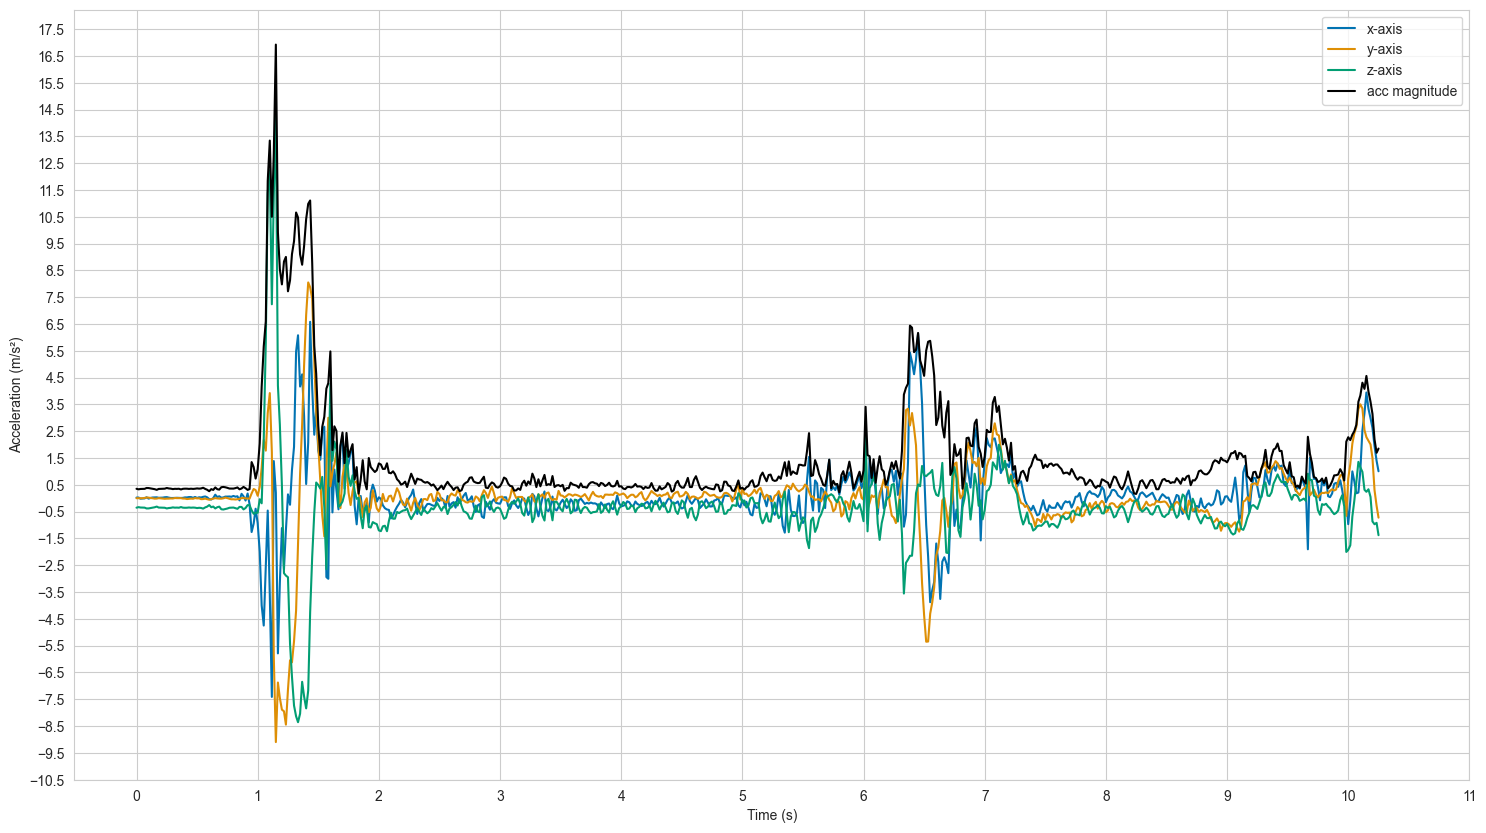

In [50]:
df = dfs_stand[0]

sns.set_style('whitegrid')
sns.set_palette('colorblind')

# plot acceleration along x, y and z axis
plt.figure(figsize=(18, 10))
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_x', label='x-axis')
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_y', label='y-axis')
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_z', label='z-axis')
sns.lineplot(data=df, x='time_s', y='acceleration_magnitude', label='acc magnitude', color='black')

plt.xticks(np.arange(0.0, 11.5, 1))
plt.yticks(np.arange(-10.5, 18, 1))

# # draw a horizontal line at y=0
# plt.axhline(y=0, color='black', linewidth=1)


plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')

# plt.title('Acceleration along x, y and z axis for Standard Sit to Stand task')
# plt.tight_layout()
plt.legend()


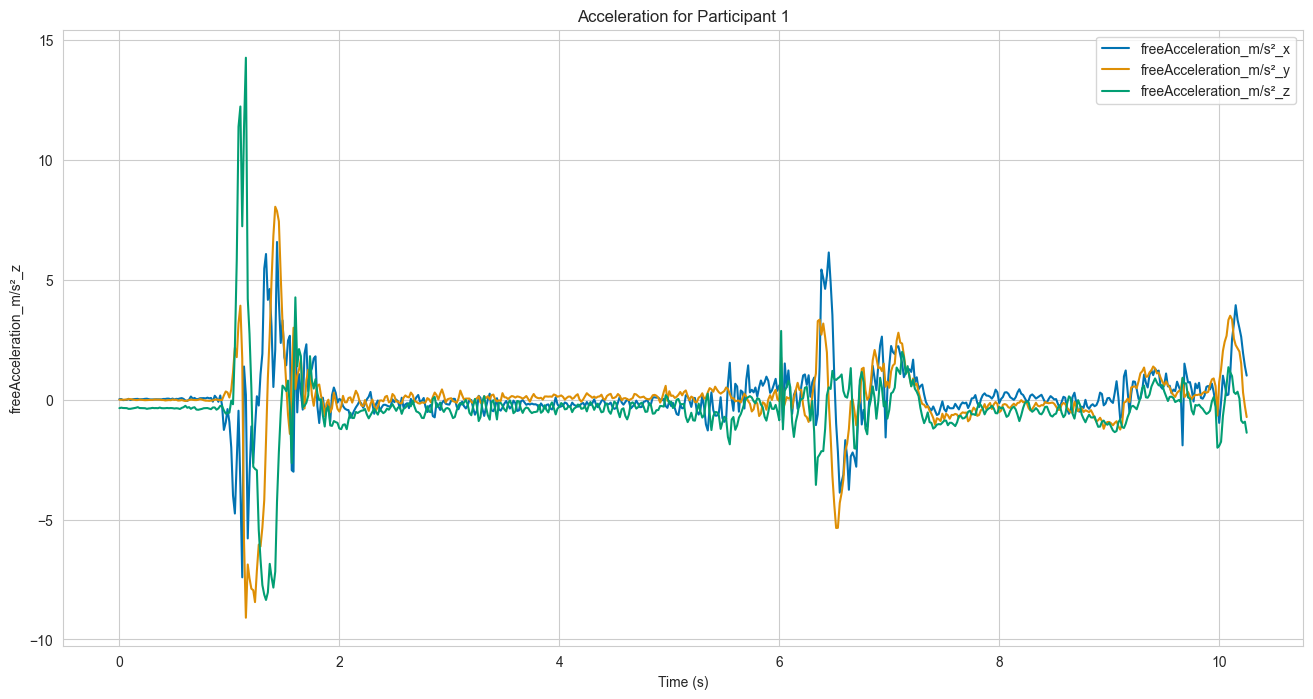

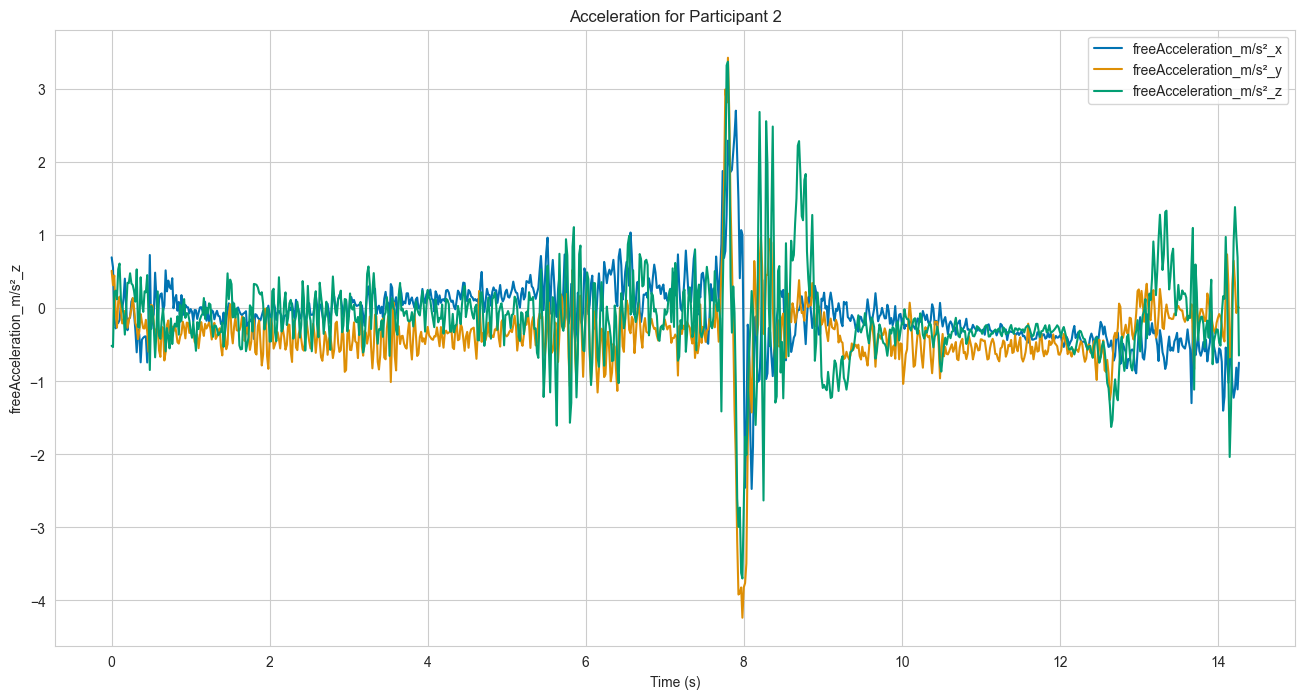

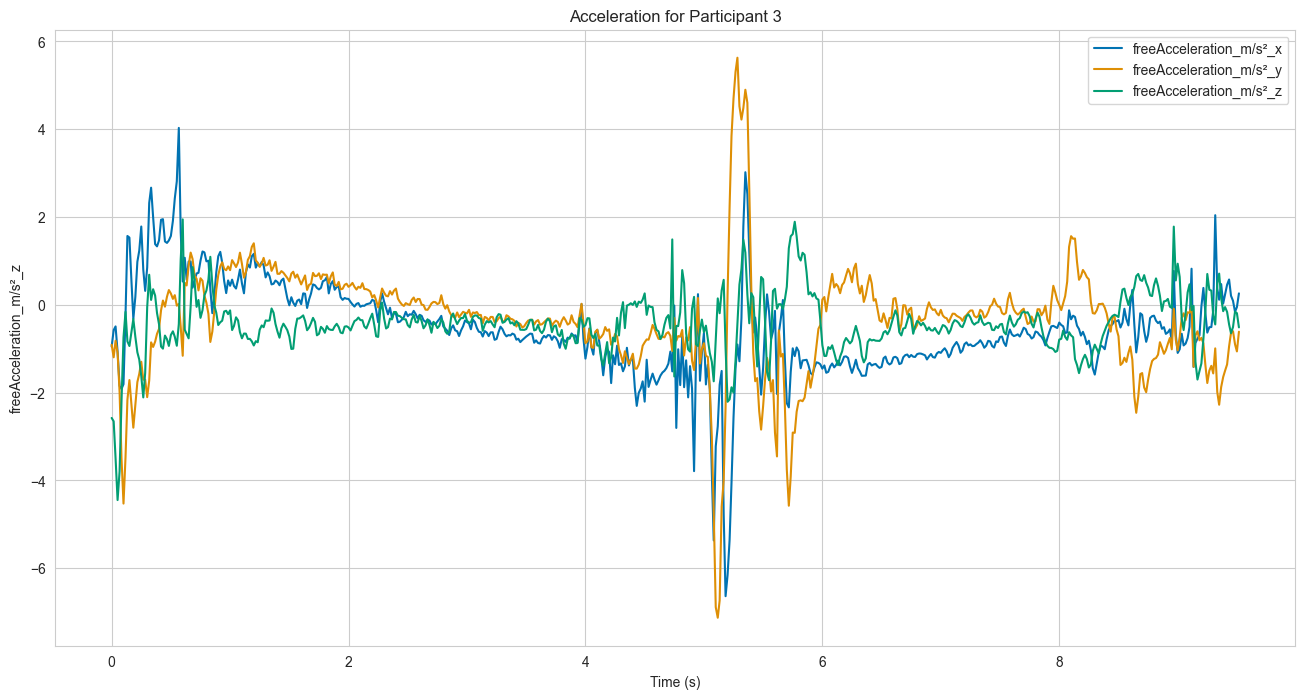

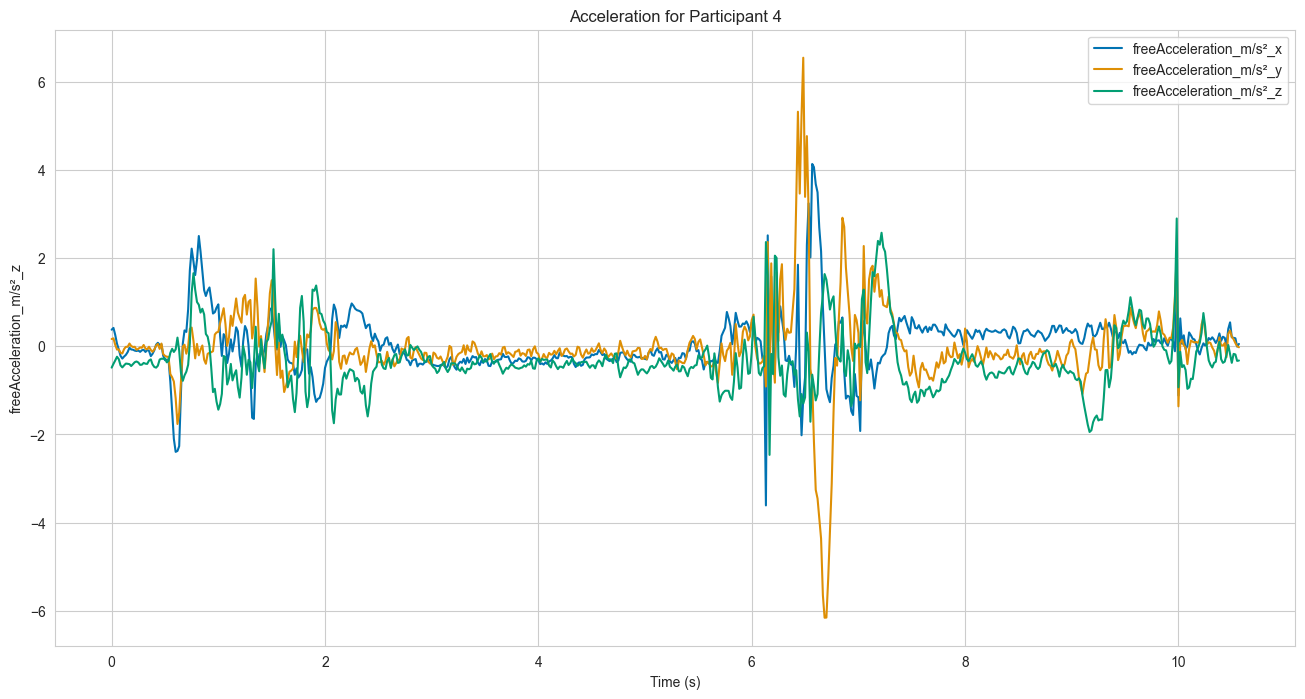

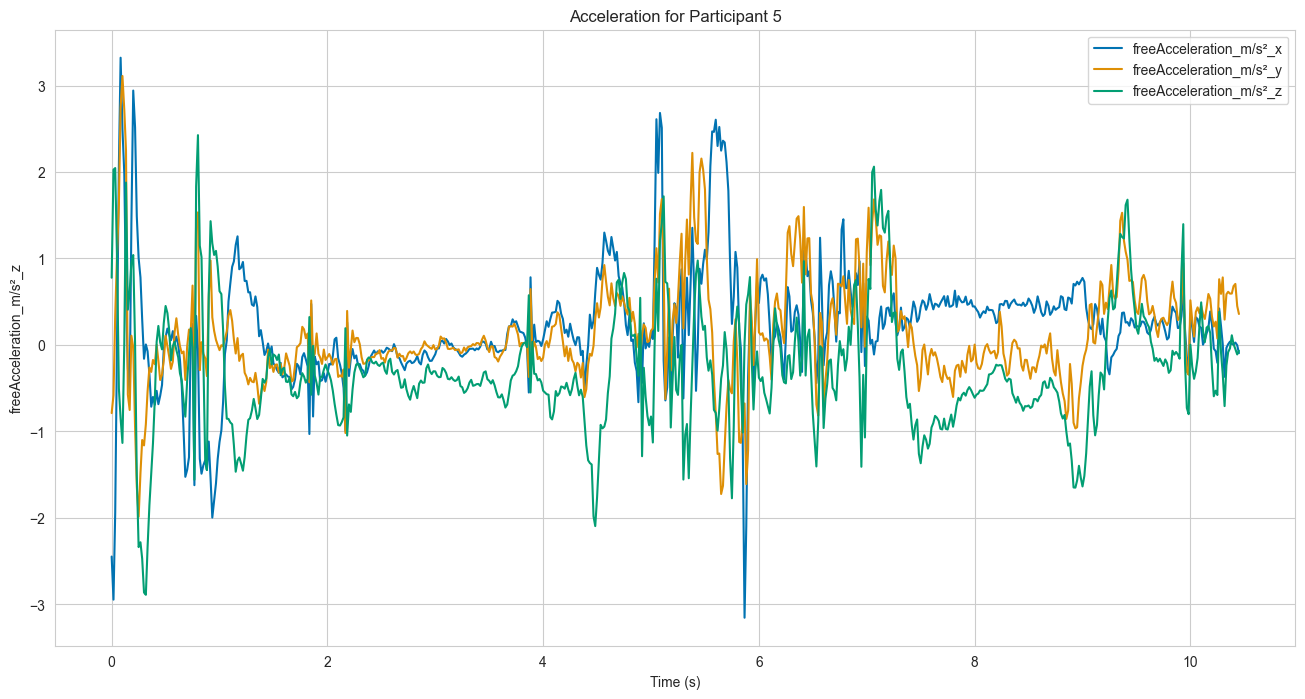

In [10]:
for i, dframe in enumerate(dfs_stand):
    plot_column(dframe, ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'])
    plt.title('Acceleration for Participant ' + str(i+1))
    plt.show()

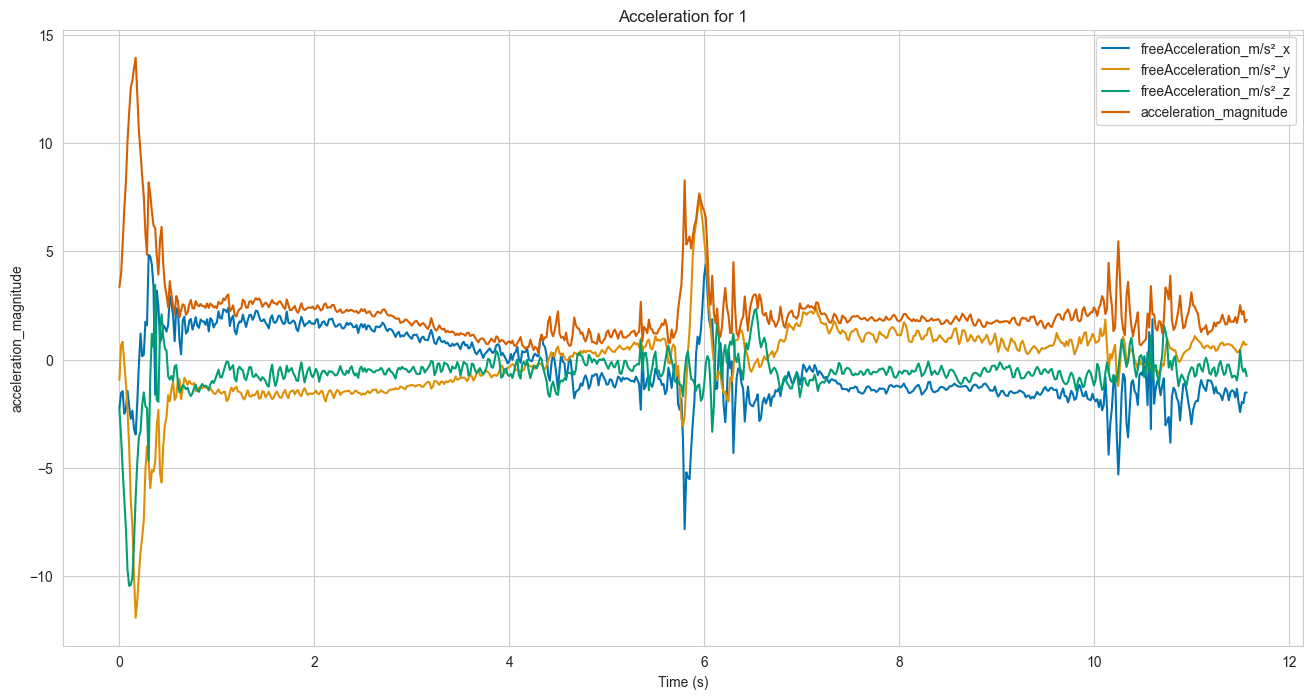

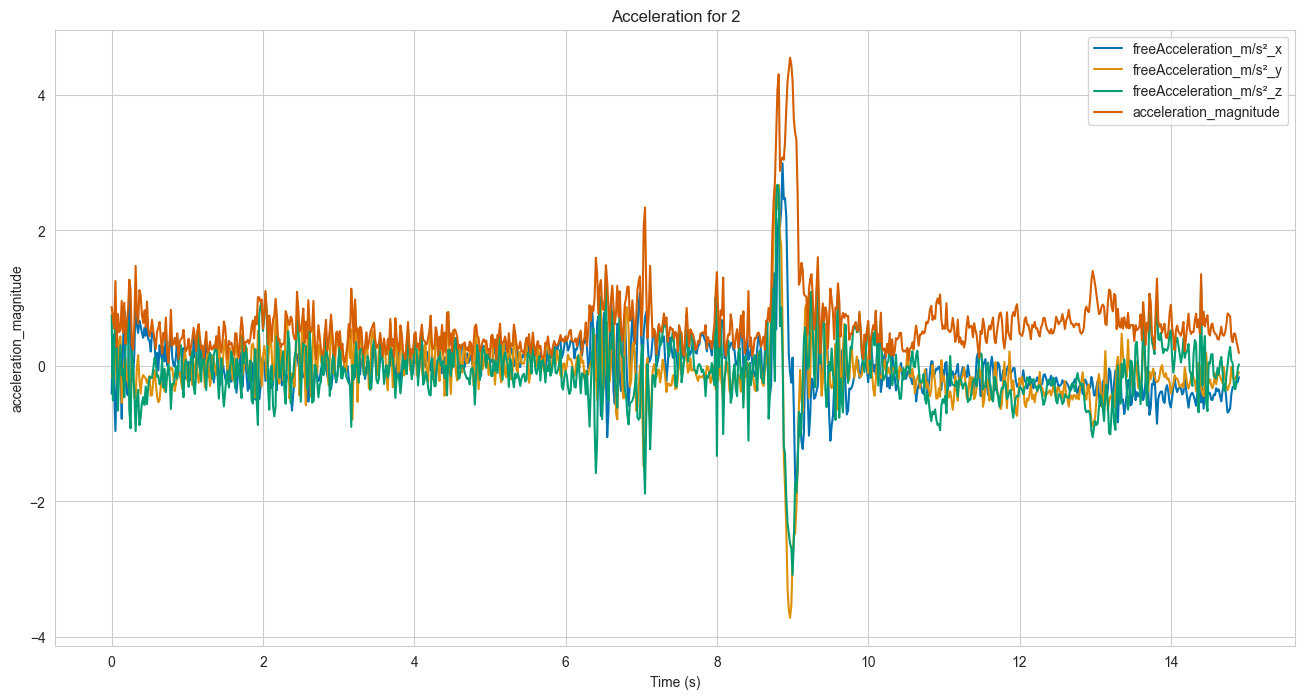

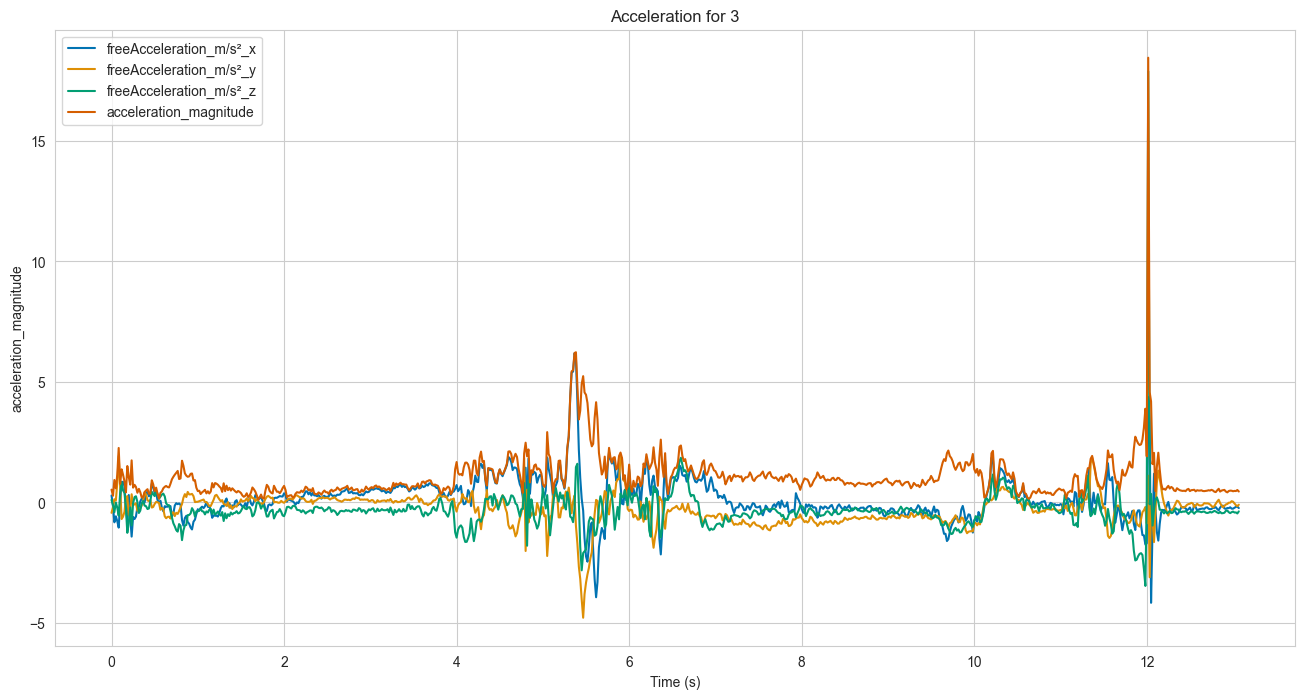

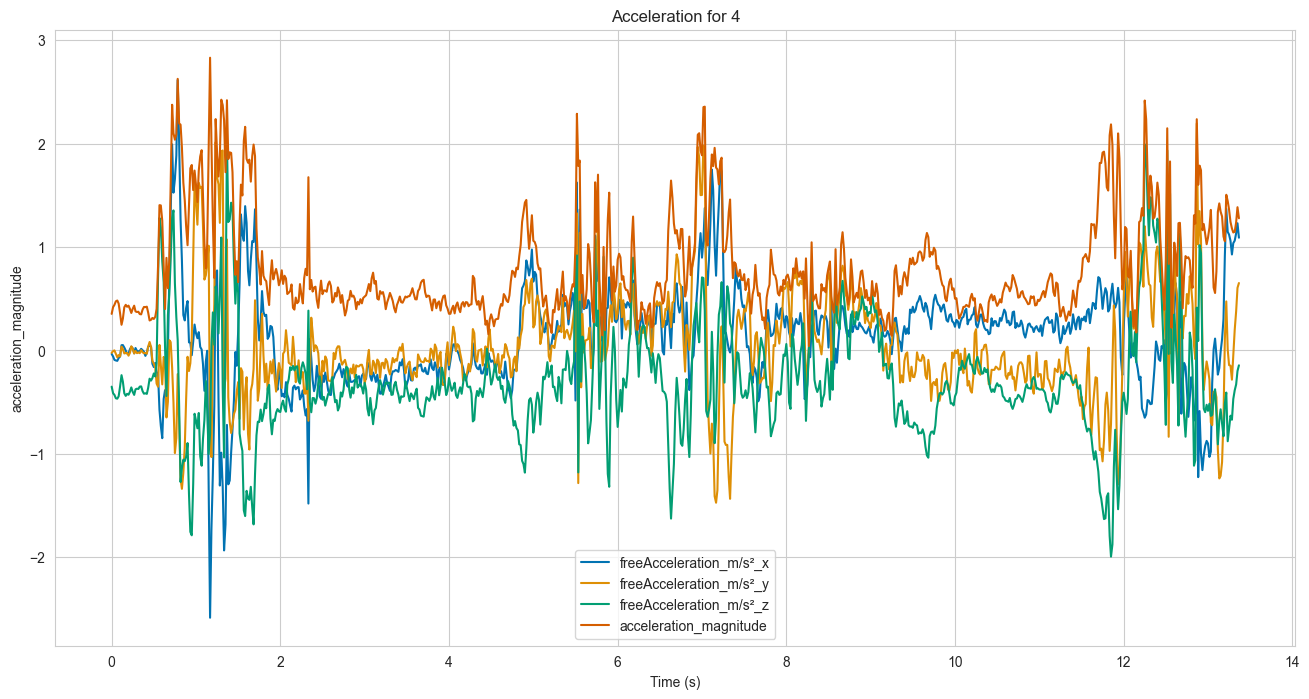

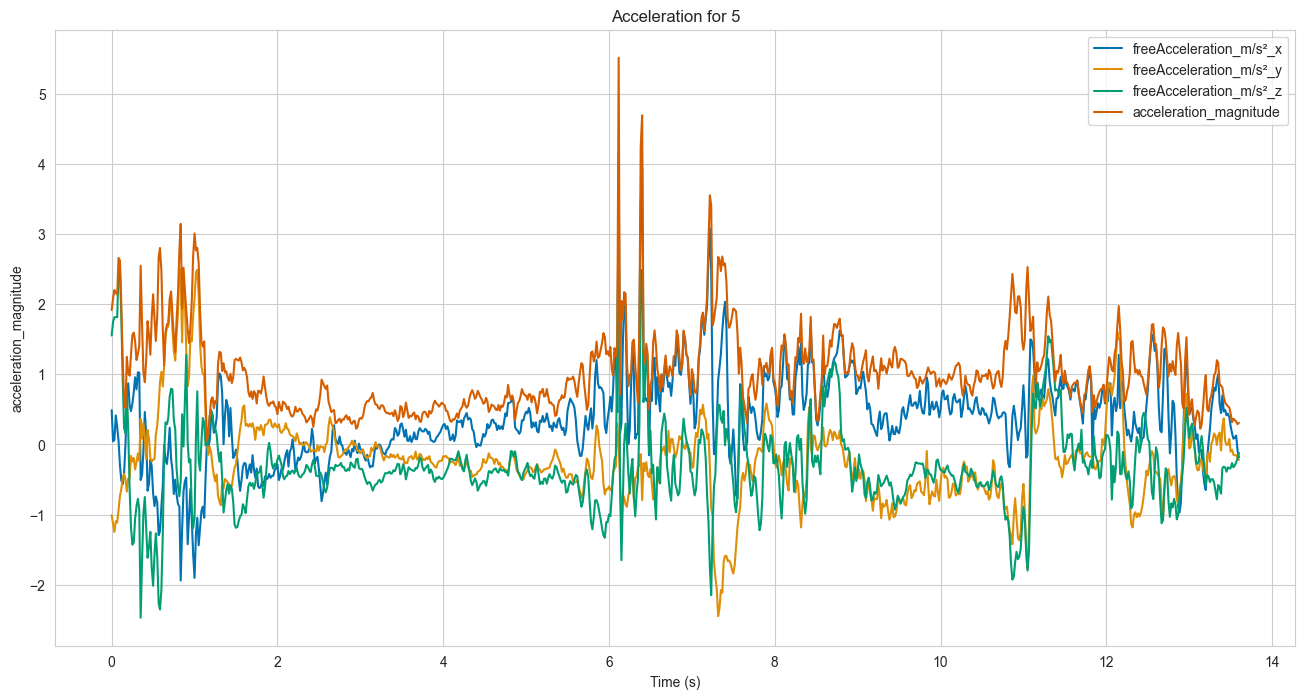

In [11]:
for i, dframe in enumerate(dfs_stand_challenge):
    plot_column(dframe, ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z', 'acceleration_magnitude'])
    plt.title('Acceleration for ' + str(i+1))
    plt.show()

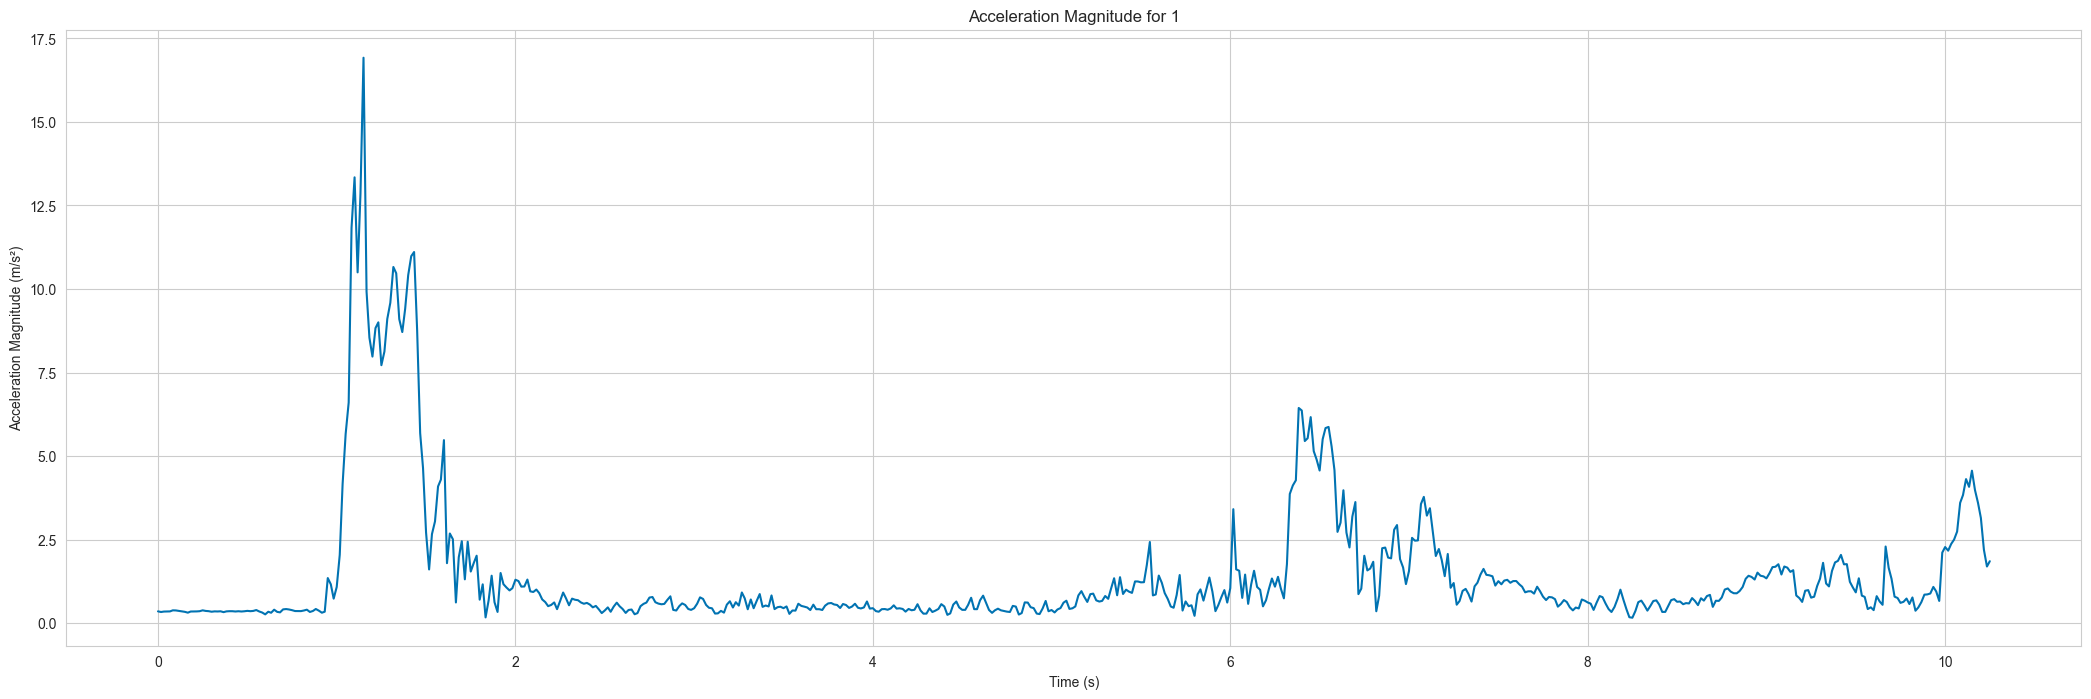

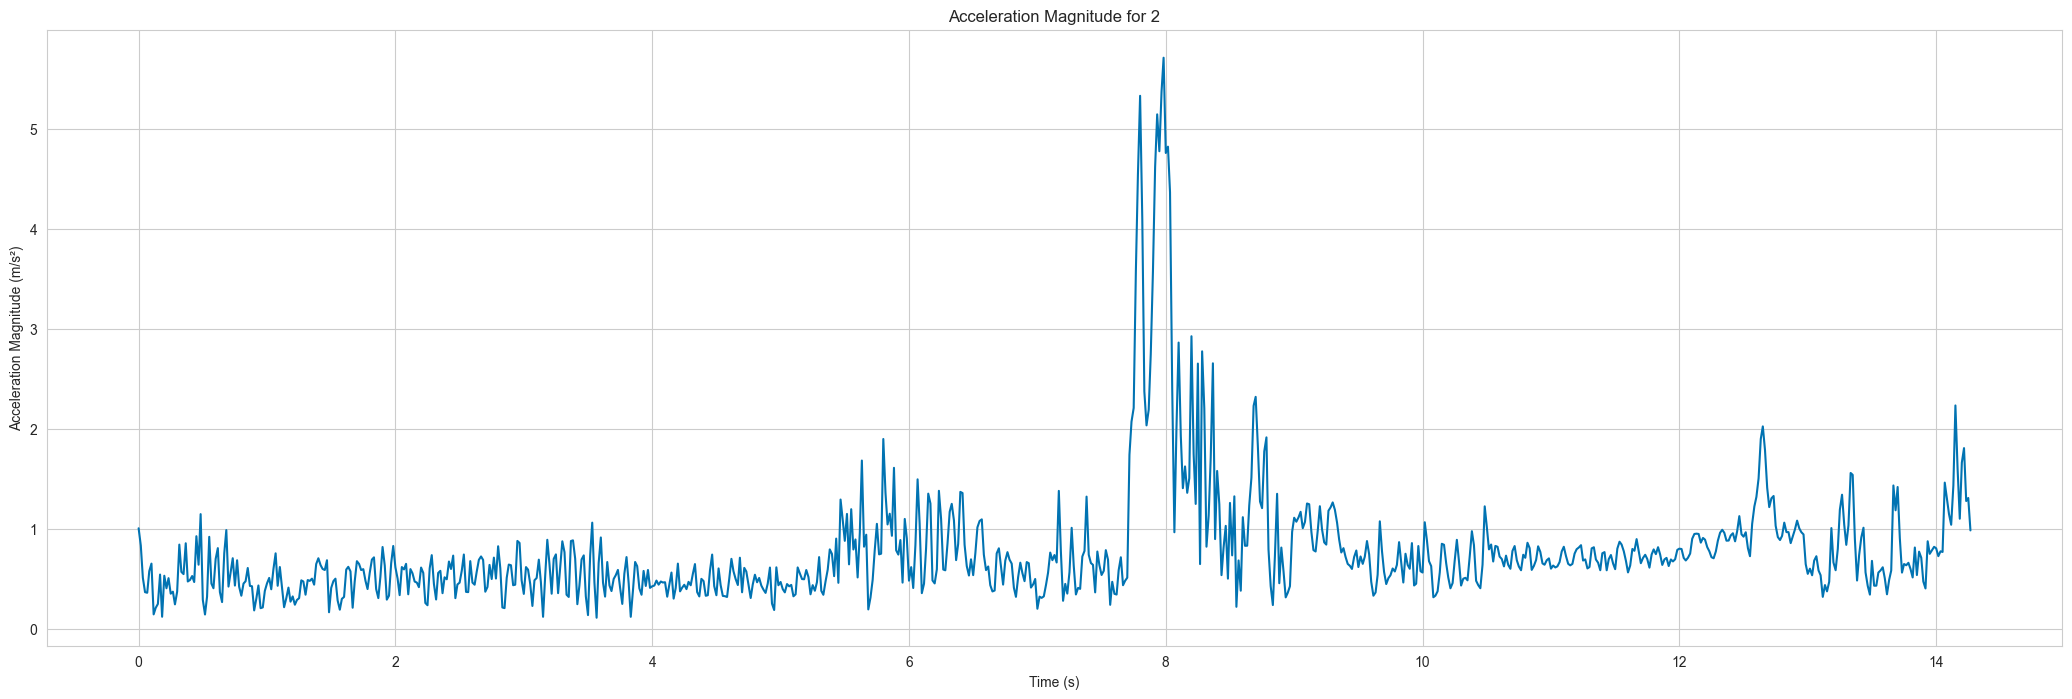

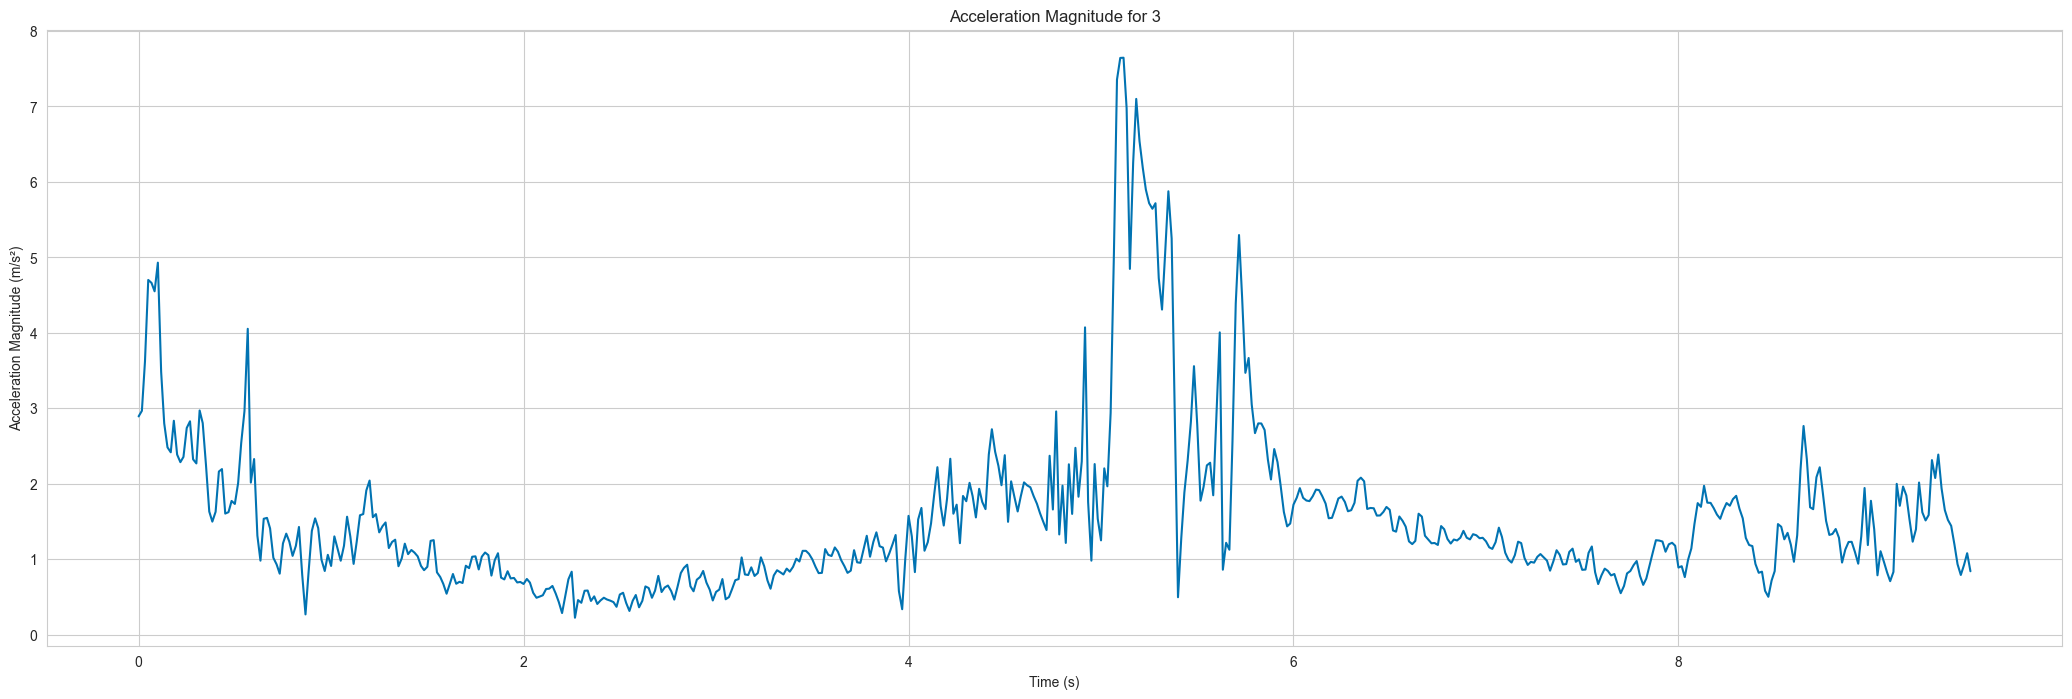

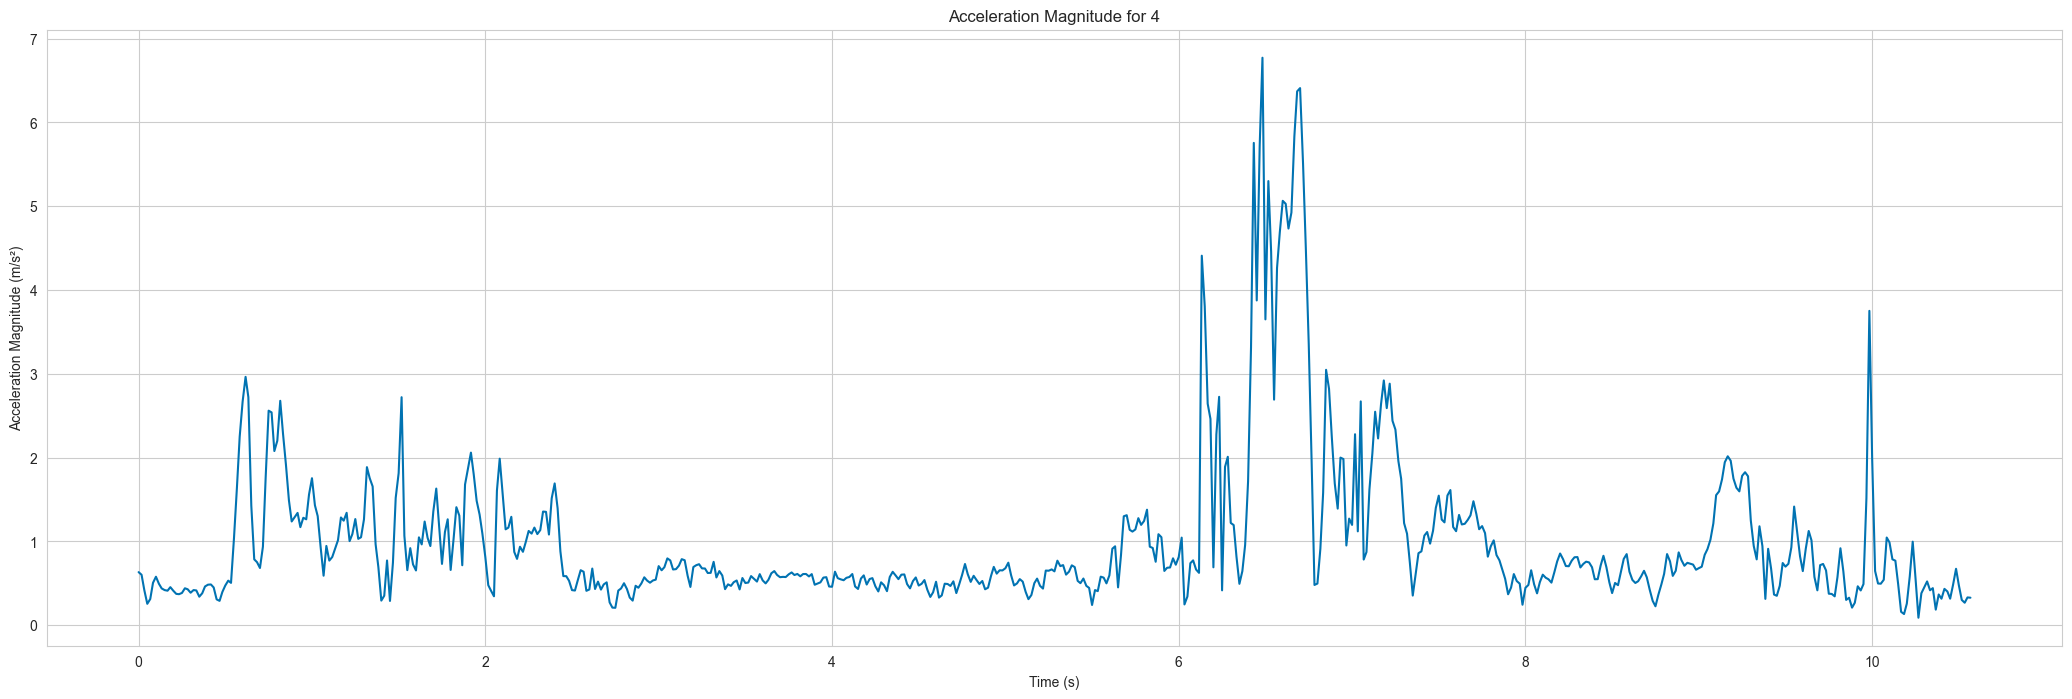

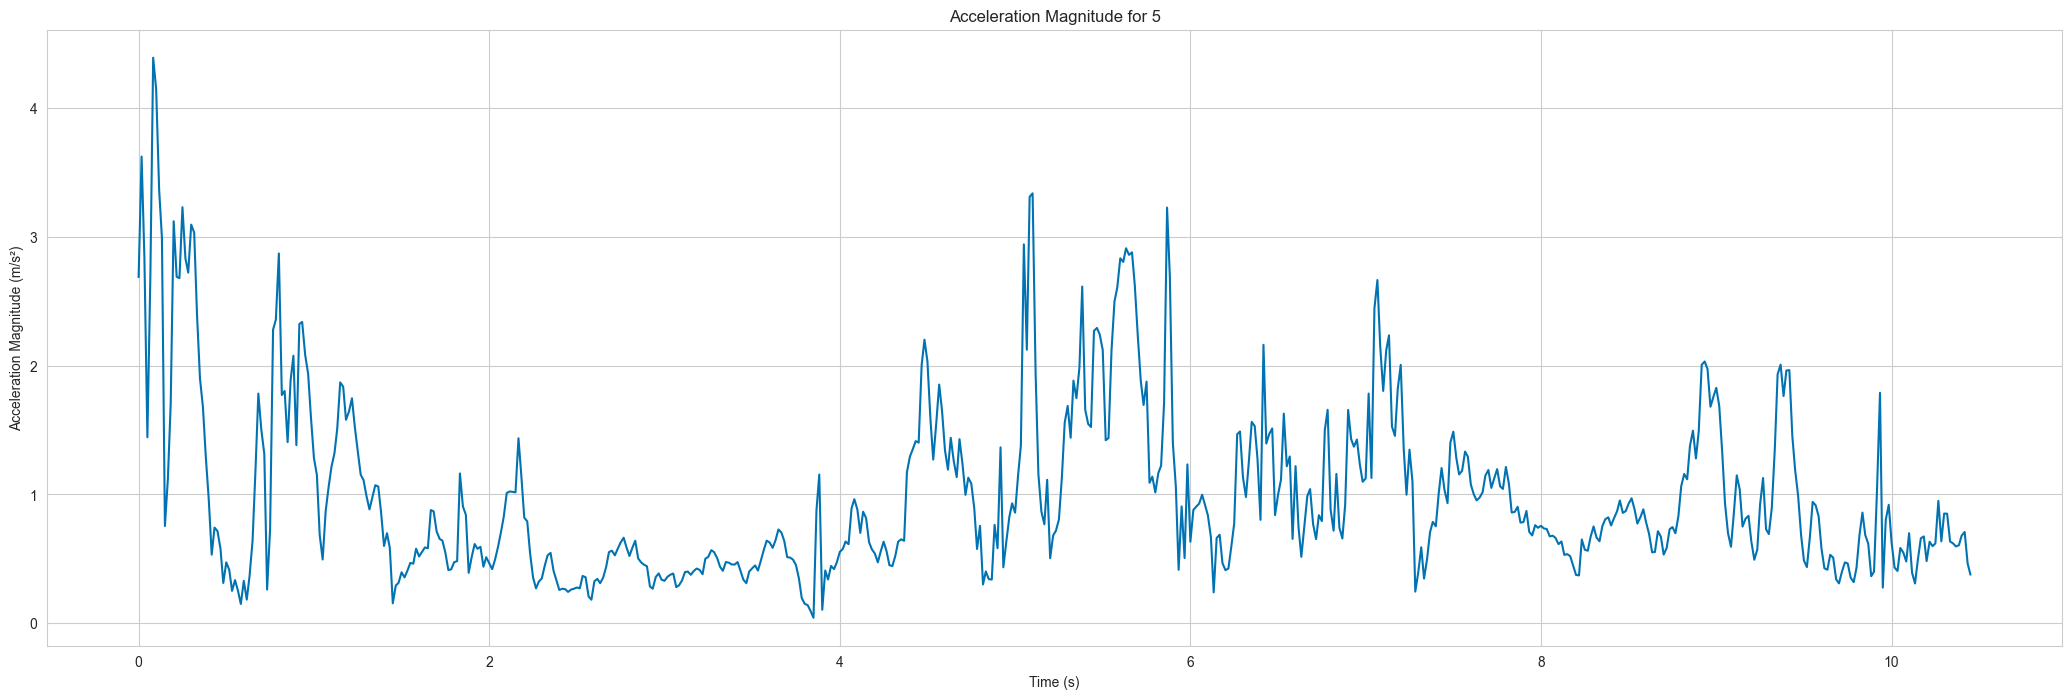

In [12]:
# plot acceleration magnitude for dfs_stand[0]
for i, dframe in enumerate(dfs_stand):
    plt.figure(figsize=(26, 8))
    plt.plot(dframe['time_s'], dframe['acceleration_magnitude'])
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration Magnitude (m/s²)')
    plt.title('Acceleration Magnitude for ' + str(i+1))
    plt.show()


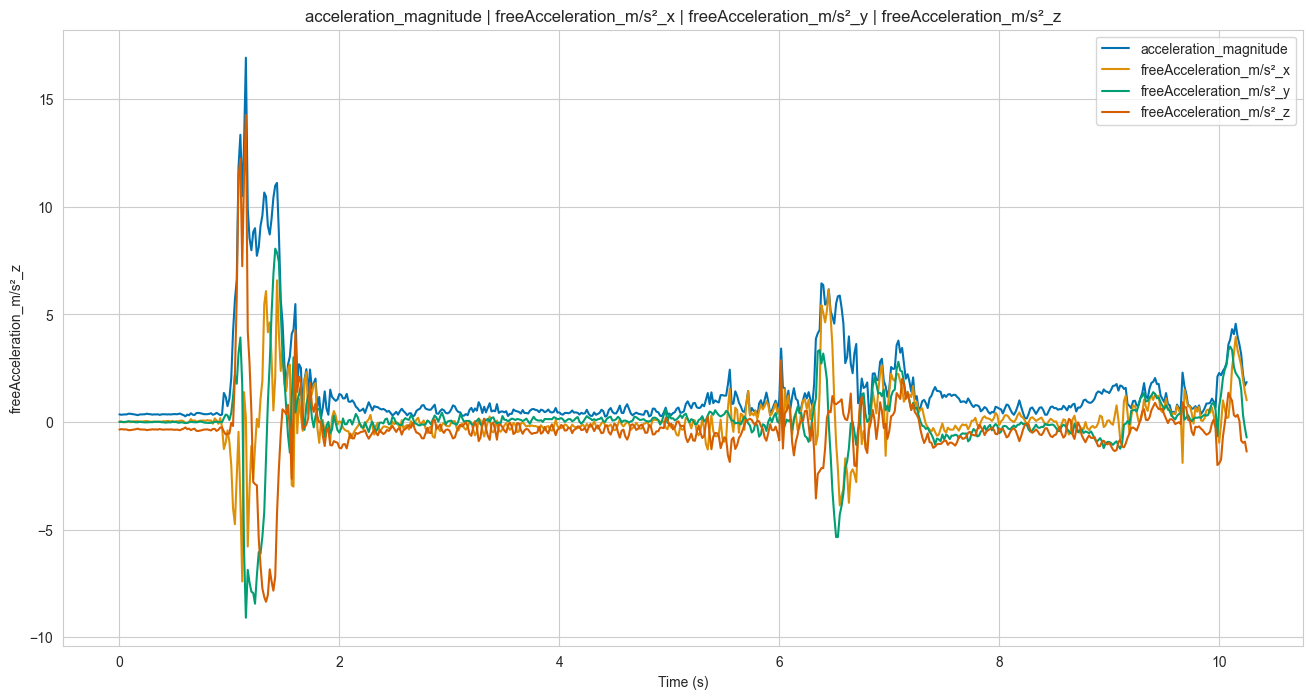

In [13]:
plot_column(dfs_stand[0], ['acceleration_magnitude', 'freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'])

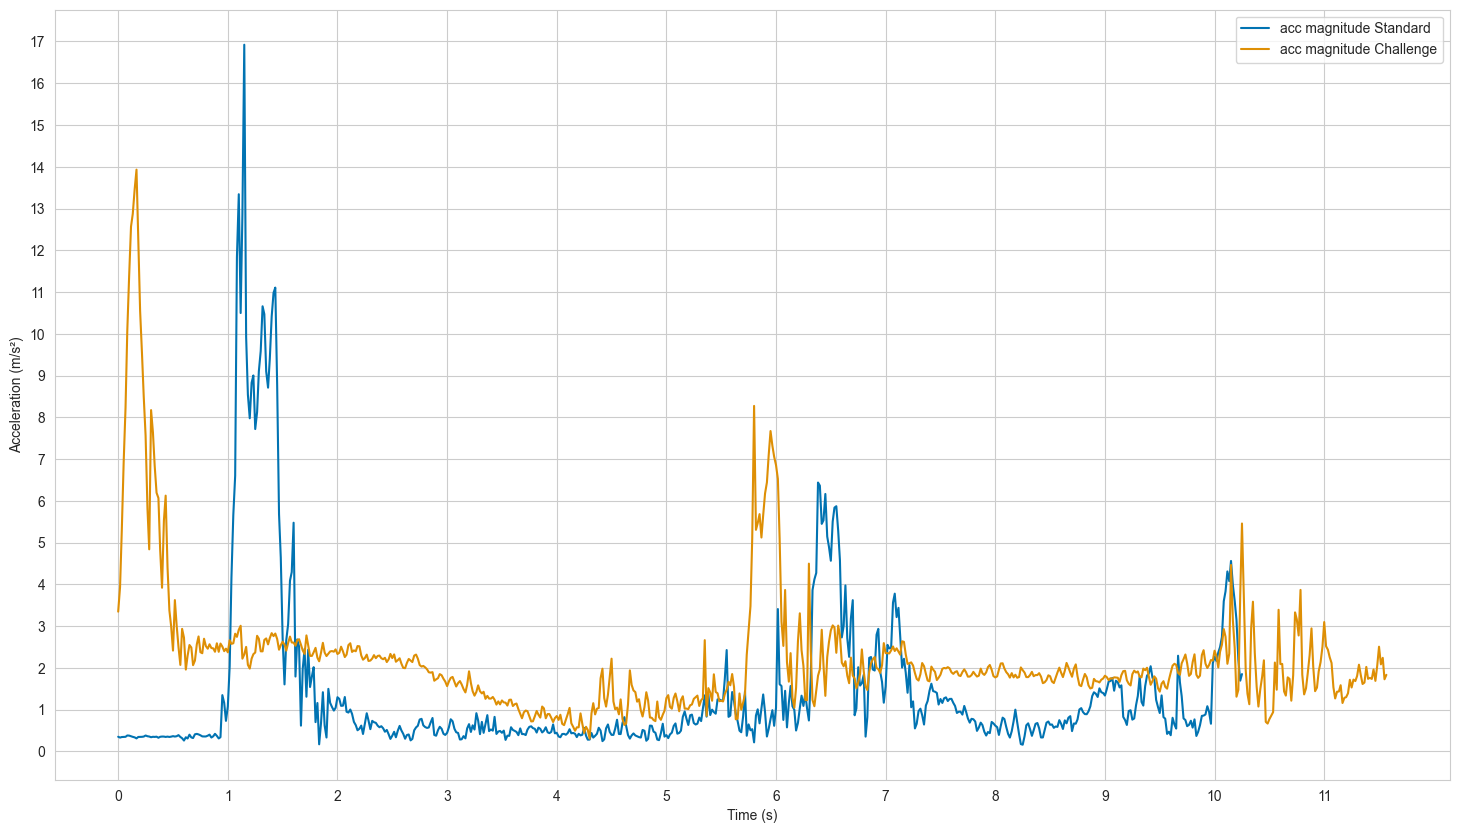

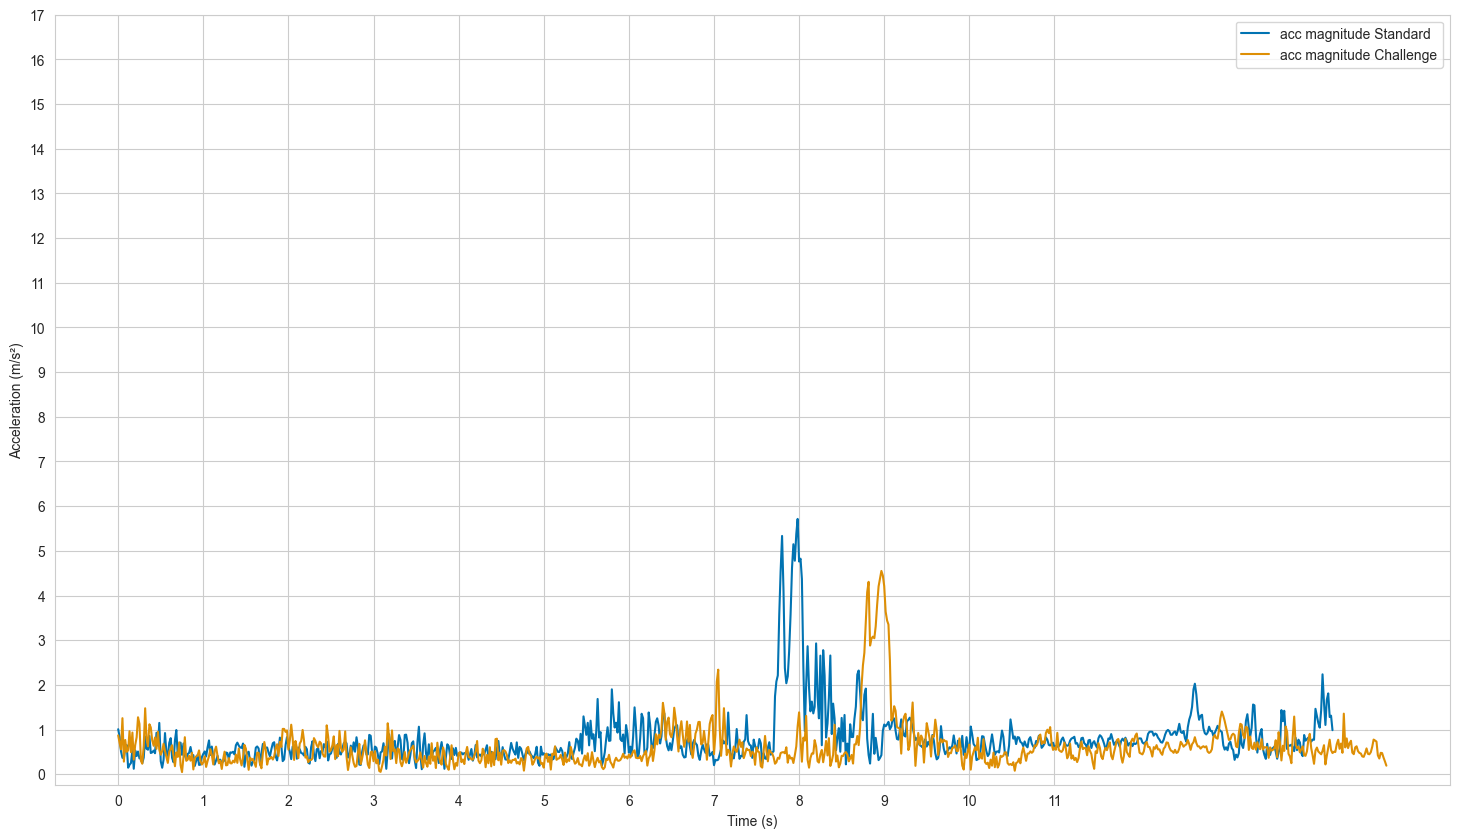

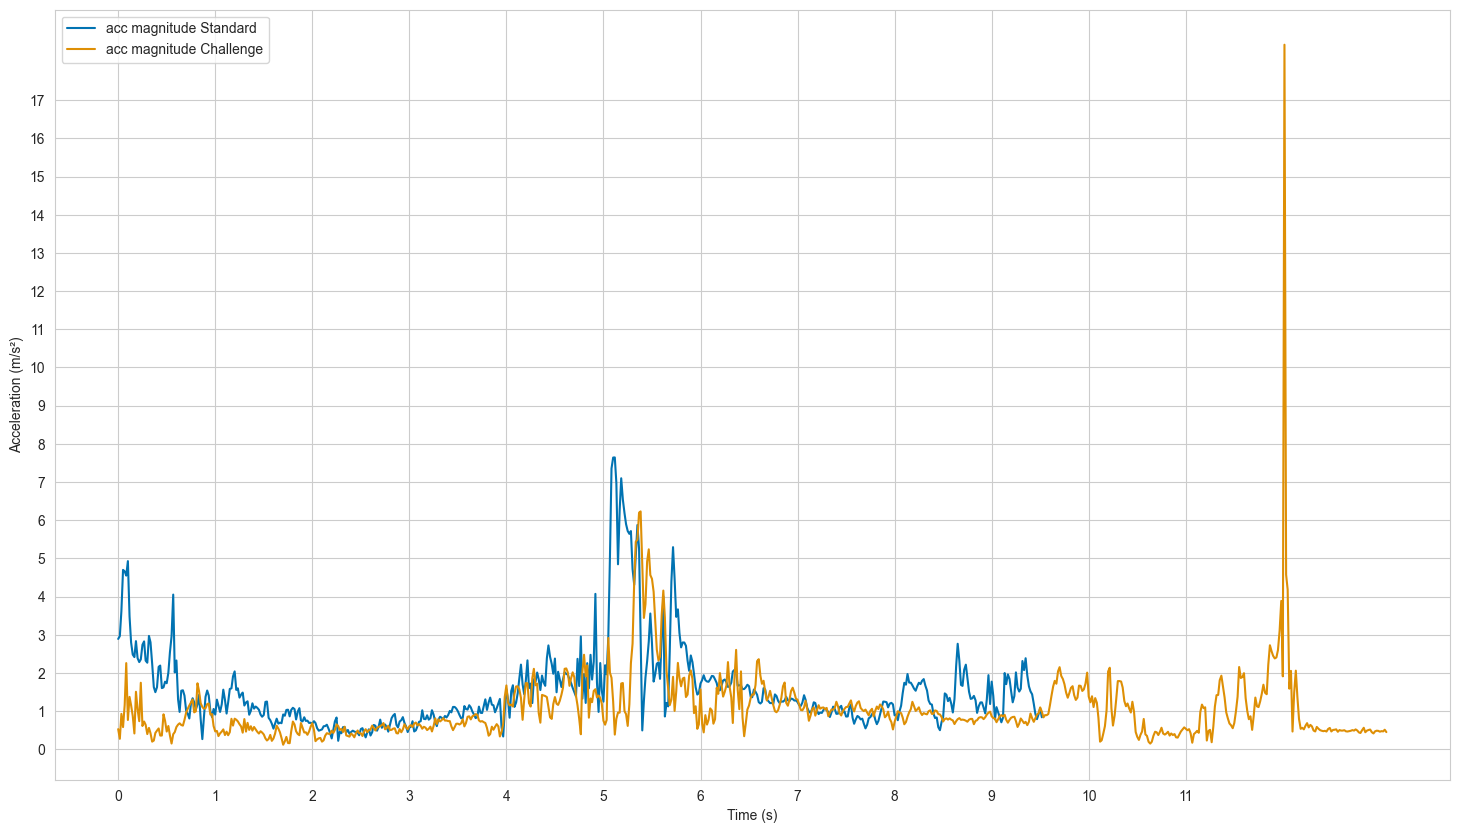

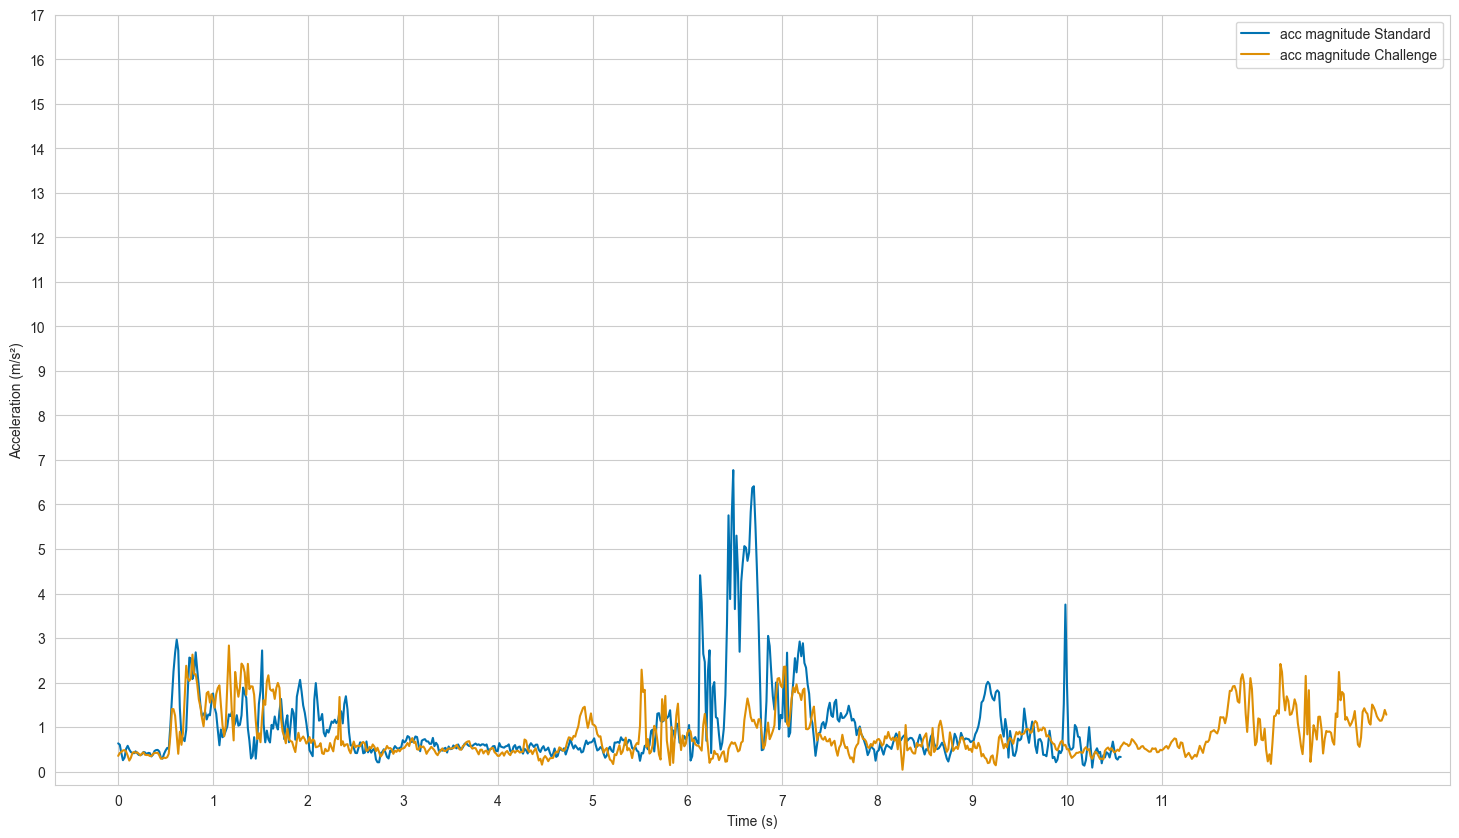

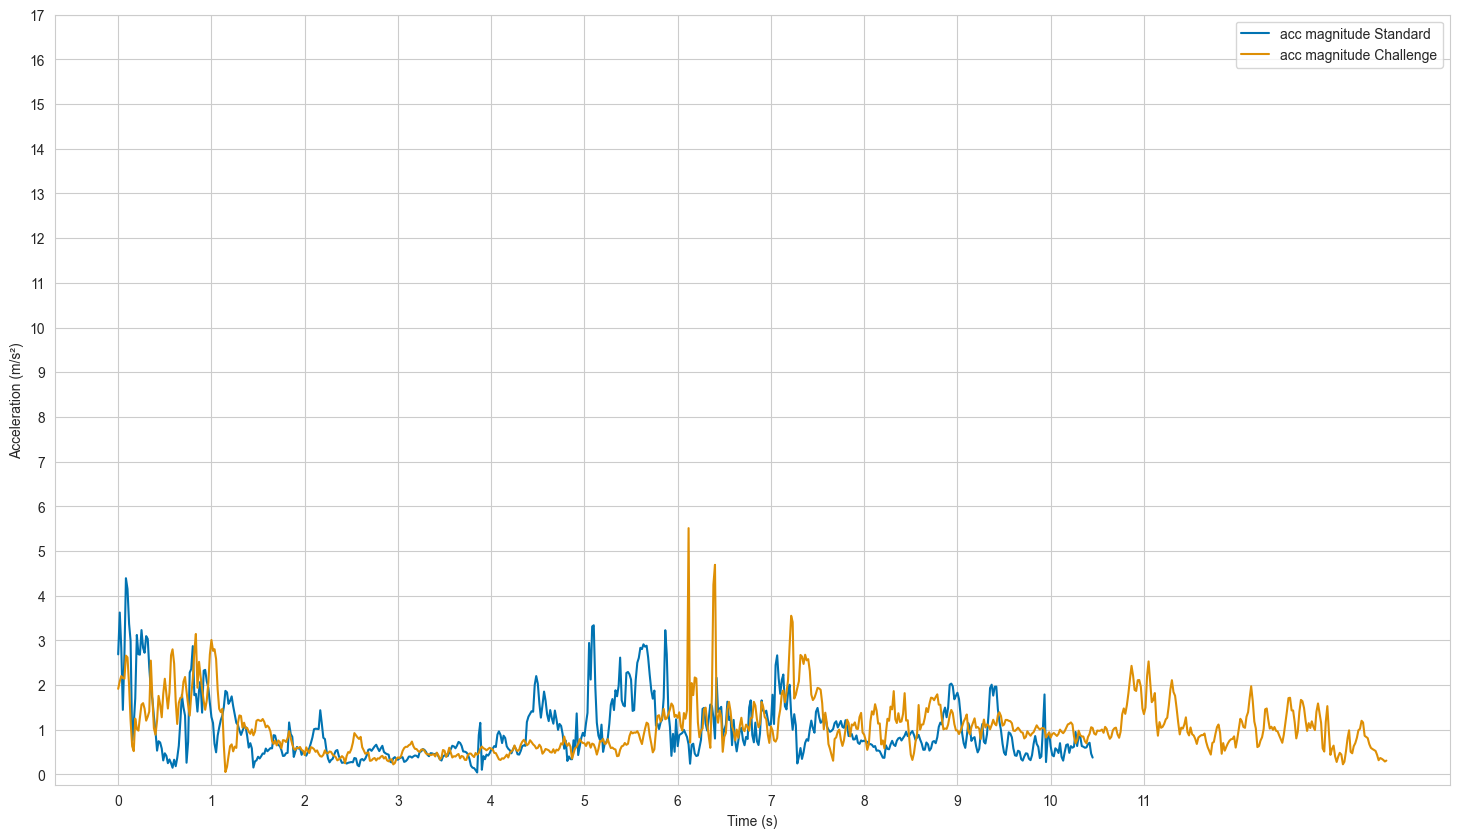

In [54]:
for i in range(len(dfs_stand)):
    df = dfs_stand[i]
    df_challenge = dfs_stand_challenge[i]

    sns.set_style('whitegrid')
    sns.set_palette('colorblind')

    # plot acceleration along x, y and z axis
    plt.figure(figsize=(18, 10))
    sns.lineplot(data=df, x='time_s', y='acceleration_magnitude', label='acc magnitude Standard')

    sns.lineplot(data=df_challenge, x='time_s', y='acceleration_magnitude', label='acc magnitude Challenge' )

    plt.xticks(np.arange(0.0, 11.5, 1))
    plt.yticks(np.arange(0, 18, 1))

    # # draw a horizontal line at y=0
    # plt.axhline(y=0, color='black', linewidth=1)


    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration (m/s²)')

    # plt.title('Acceleration along x, y and z axis for Standard Sit to Stand task')
    # plt.tight_layout()
    plt.legend()


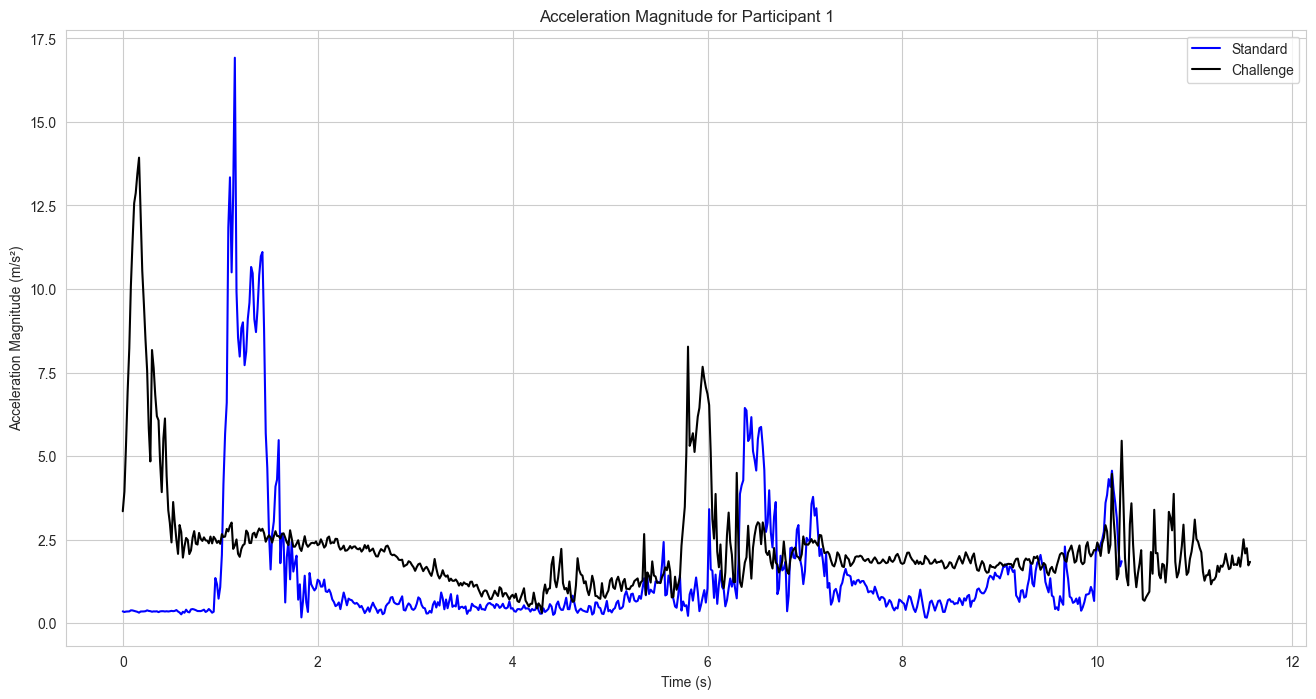

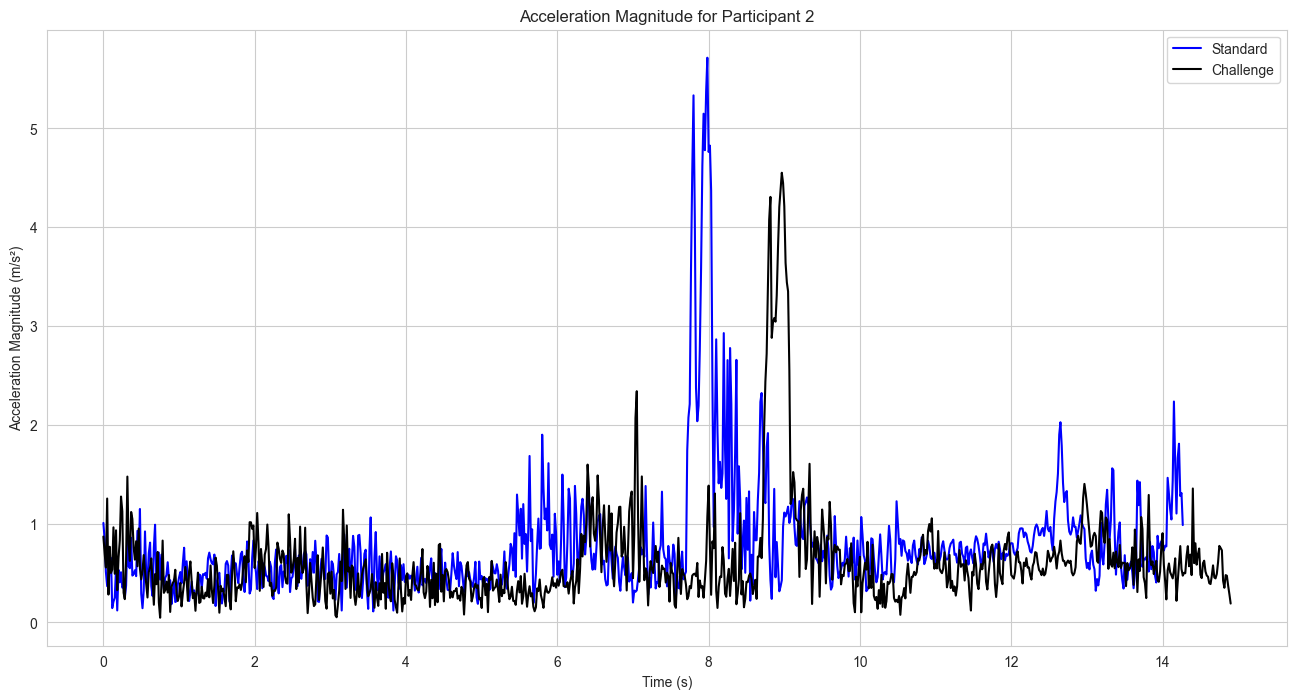

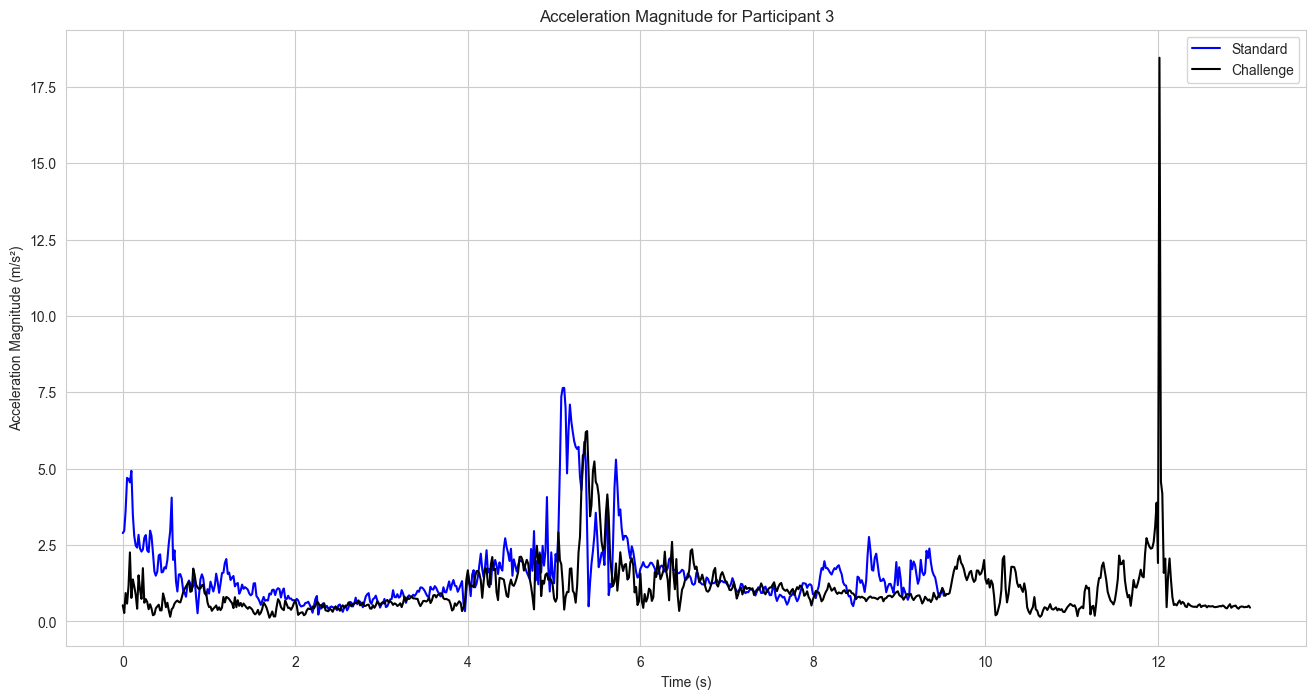

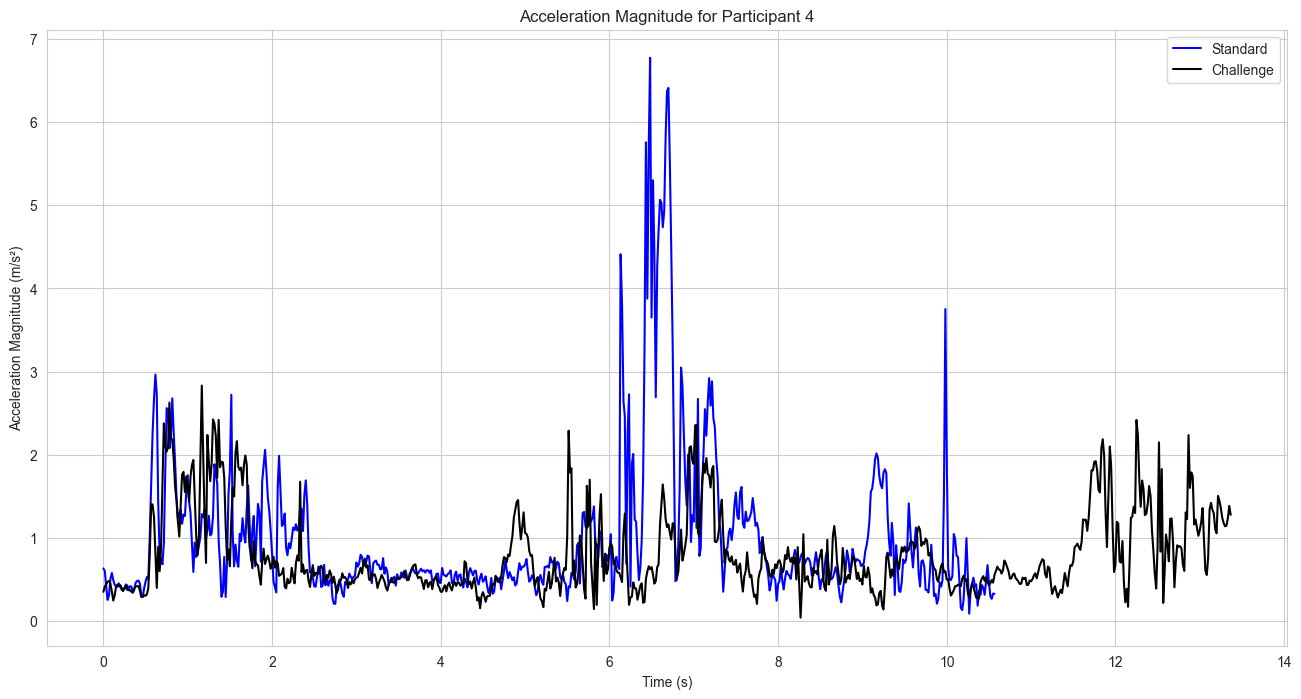

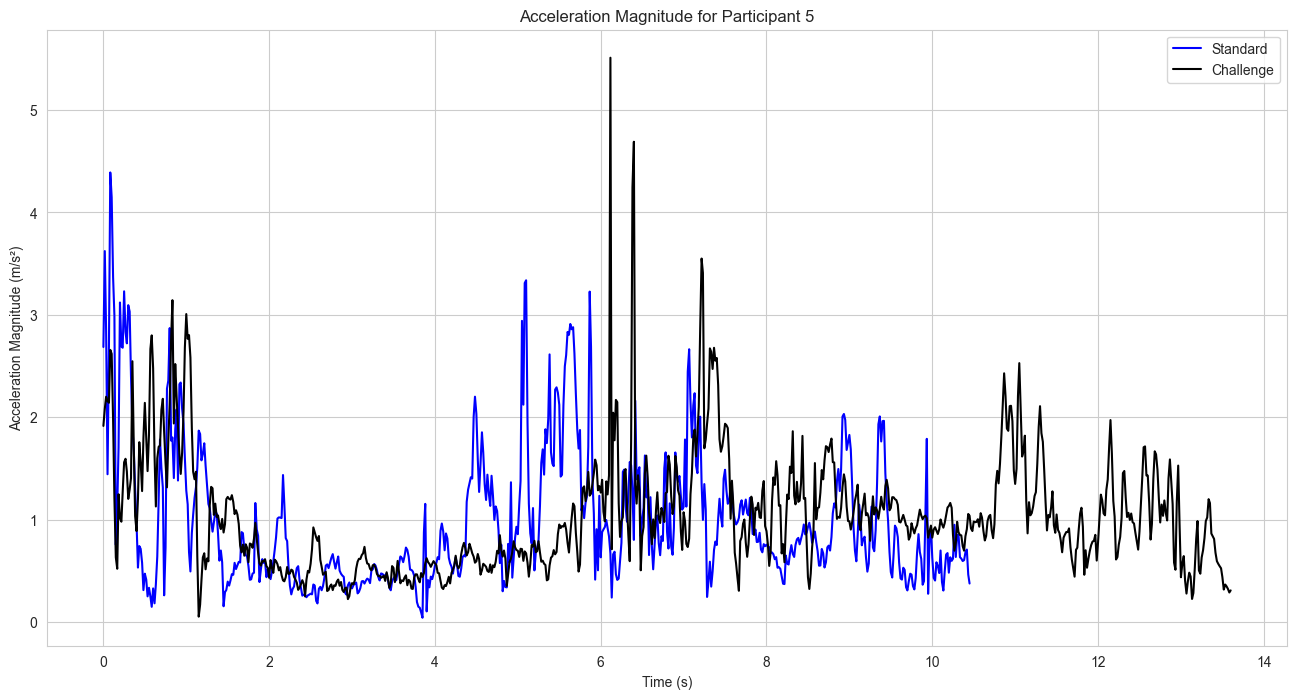

In [14]:
for i in range(len(dfs_stand)):
    # plot acceleration magnitude for dfs_stand[i] and dfs_stand_challenge[i]
    plt.figure(figsize=(16, 8))
    plt.plot(dfs_stand[i]['time_s'], dfs_stand[i]['acceleration_magnitude'], label='Standard', color='blue')
    plt.plot(dfs_stand_challenge[i]['time_s'], dfs_stand_challenge[i]['acceleration_magnitude'], label='Challenge', color='black')
    plt.xlabel('Time (s)')
    plt.legend()
    plt.ylabel('Acceleration Magnitude (m/s²)')
    plt.title('Acceleration Magnitude for Participant ' + str(i+1))
    plt.show()

Mean of acceleration magnitude for standard is 1.1544182283023199
Mean of acceleration magnitude for challenge is 1.1459959440980225


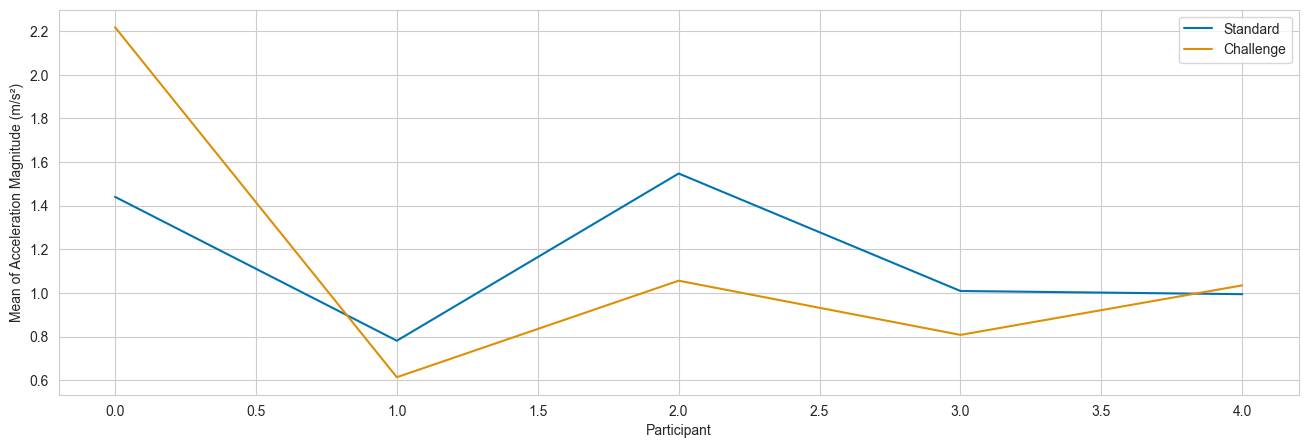

In [15]:
means_standard = []
means_challenge = []
for df in dfs_stand:
    # calculate mean of acceleration magnitude
    means_standard.append(df['acceleration_magnitude'].mean())

for df in dfs_stand_challenge:
    means_challenge.append(df['acceleration_magnitude'].mean())

print(f"Mean of acceleration magnitude for standard is {np.mean(means_standard)}")
print(f"Mean of acceleration magnitude for challenge is {np.mean(means_challenge)}")

# plot the means of acceleration magnitude for standard and challenge
plt.figure(figsize=(16, 5))
plt.plot(means_standard, label='Standard')
plt.plot(means_challenge, label='Challenge')
plt.xlabel('Participant')
plt.ylabel('Mean of Acceleration Magnitude (m/s²)')
plt.legend()
plt.show()

In [16]:
print('Standard')
print('--------------------------------')
for i, dframe in enumerate(dfs_stand):
    print(f"Number of seconds in {i}th participant is {dframe['time_s'].iloc[-1]}")

print('\n\n')
print('Challenge')
print('--------------------------------')
for i, dframe in enumerate(dfs_stand_challenge):
    print(f"Number of seconds in {i}th participant is {dframe['time_s'].iloc[-1]}")

Standard
--------------------------------
Number of seconds in 0th participant is 10.25
Number of seconds in 1th participant is 14.267
Number of seconds in 2th participant is 9.517
Number of seconds in 3th participant is 10.567
Number of seconds in 4th participant is 10.45



Challenge
--------------------------------
Number of seconds in 0th participant is 11.567
Number of seconds in 1th participant is 14.9
Number of seconds in 2th participant is 13.067
Number of seconds in 3th participant is 13.367
Number of seconds in 4th participant is 13.6


<Figure size 2600x800 with 0 Axes>

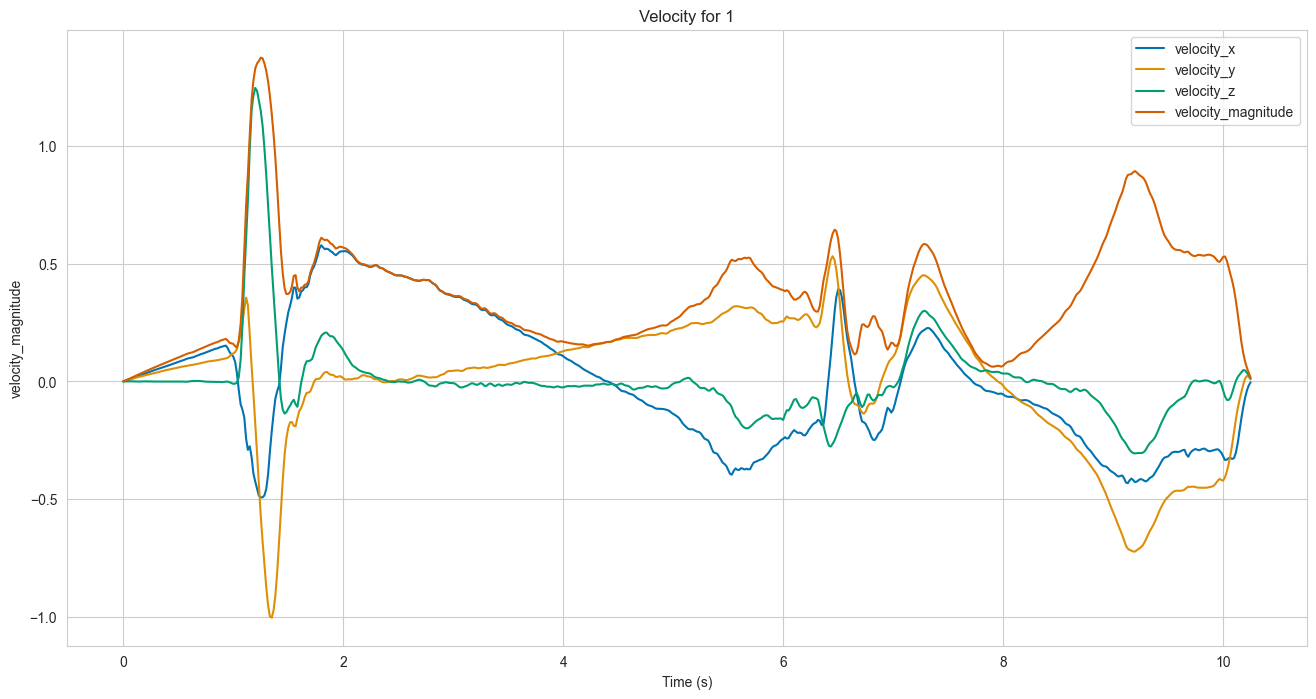

<Figure size 2600x800 with 0 Axes>

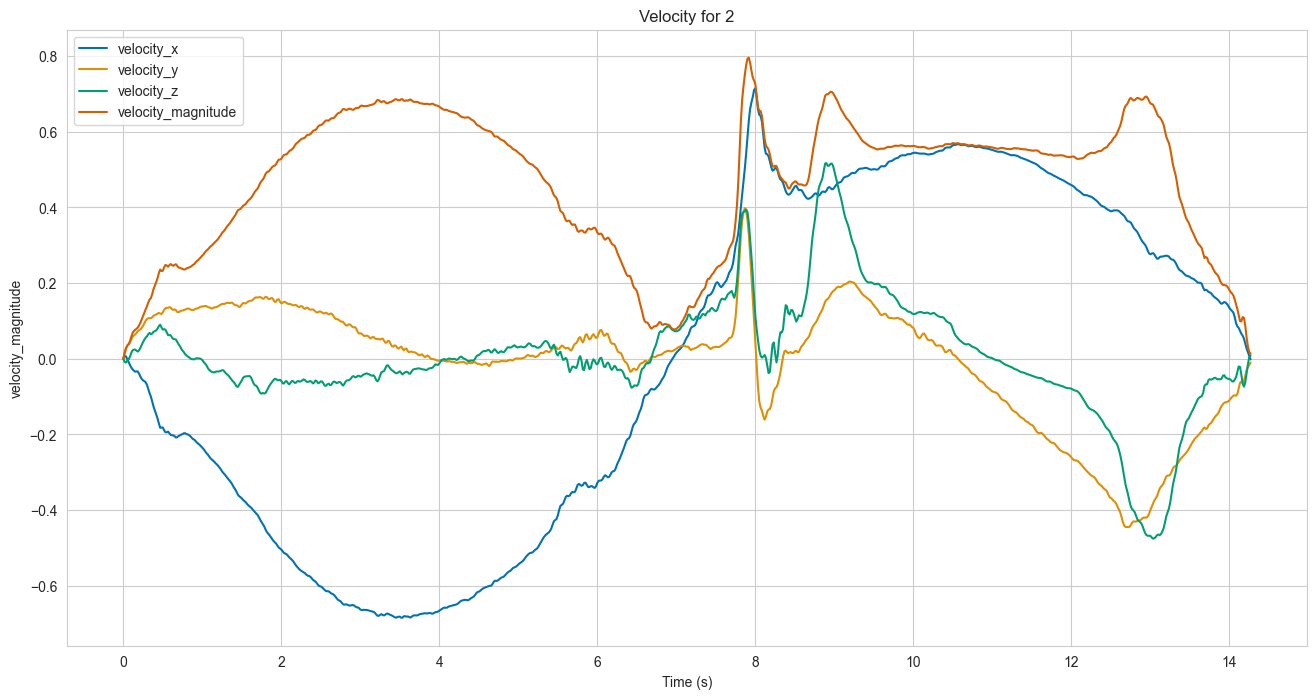

<Figure size 2600x800 with 0 Axes>

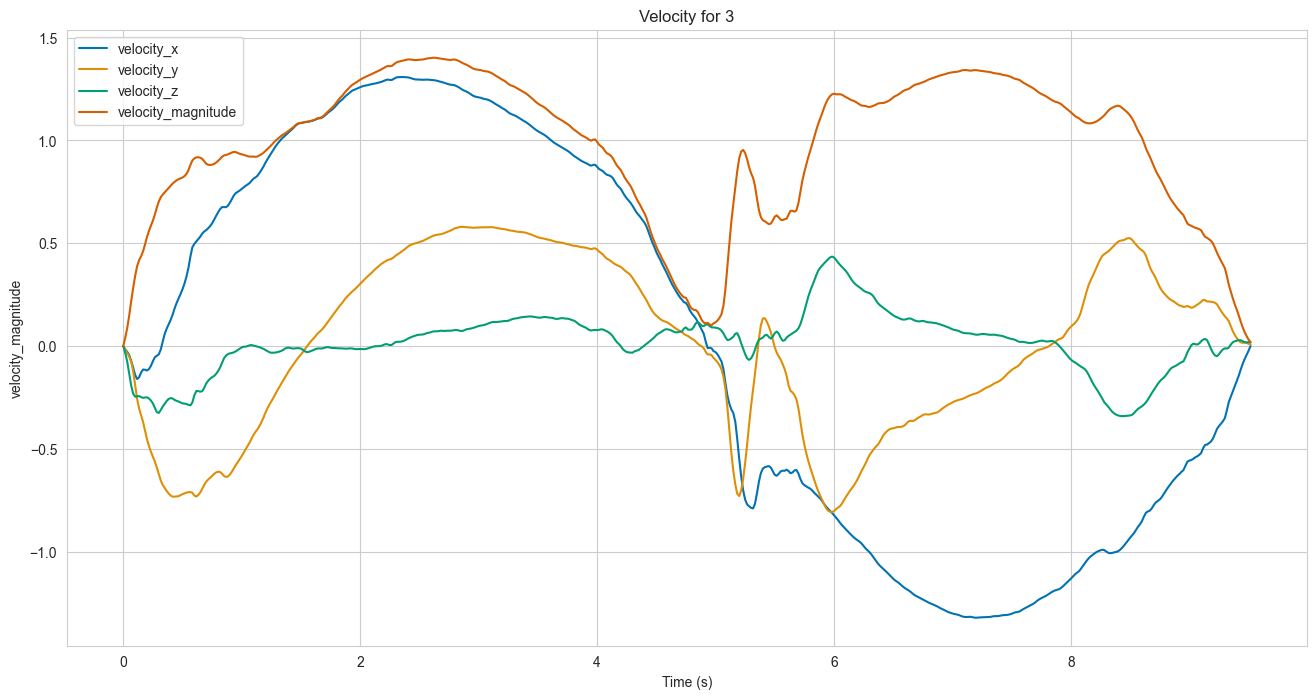

<Figure size 2600x800 with 0 Axes>

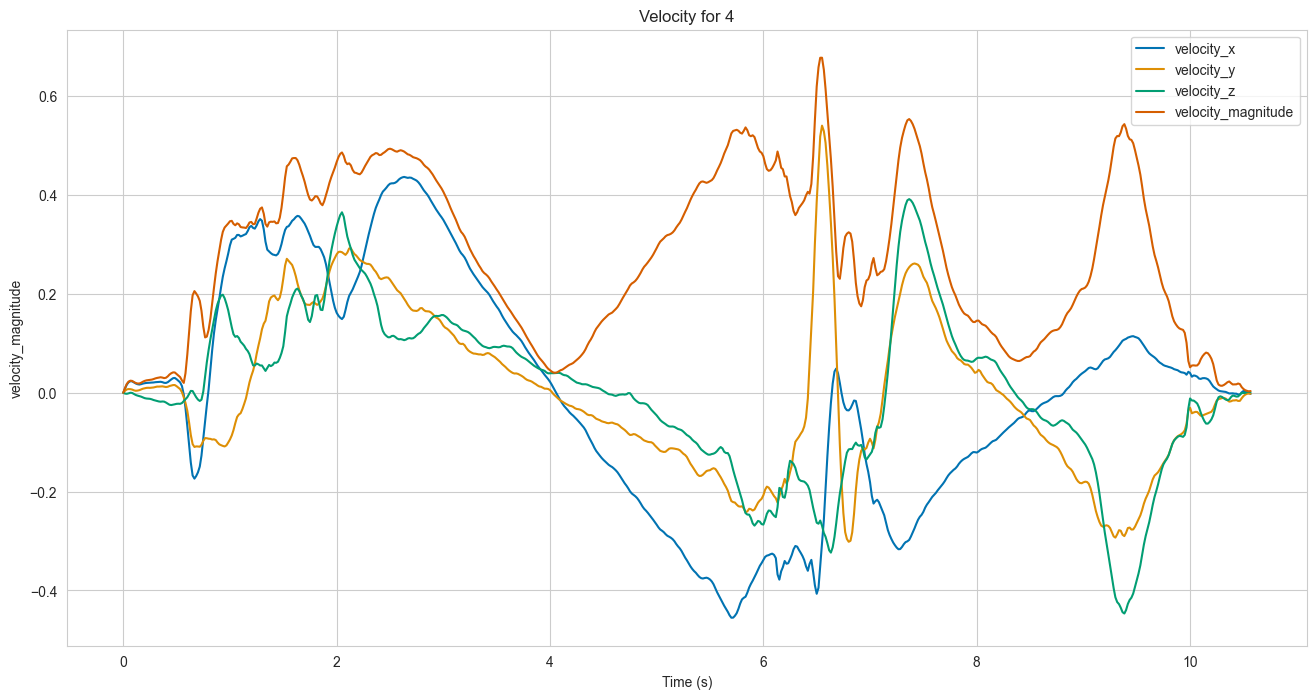

<Figure size 2600x800 with 0 Axes>

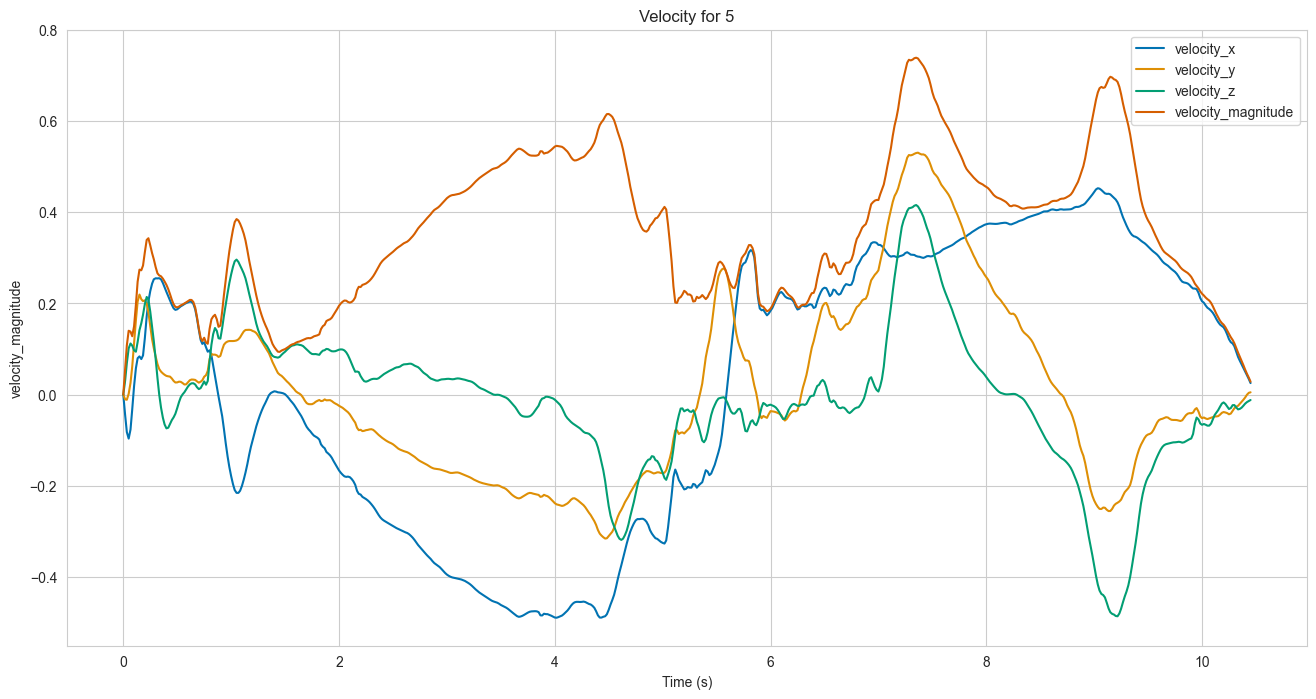

In [17]:
for i, dframe in enumerate(dfs_stand):
    plt.figure(figsize=(26, 8))
    plot_column(dframe, ['velocity_x', 'velocity_y', 'velocity_z', 'velocity_magnitude'])
    plt.title('Velocity for ' + str(i+1))
    plt.show()



In [18]:
# Make lists of time taken for each participant to complete the challenge
time_taken_standard = []
for i, dframe in enumerate(dfs_stand):
    time_taken_standard.append(dframe['time_s'].iloc[-1])

time_taken_challenge = []
for i, dframe in enumerate(dfs_stand_challenge):
    time_taken_challenge.append(dframe['time_s'].iloc[-1])

print(time_taken_standard)
print(time_taken_challenge)


[np.float64(10.25), np.float64(14.267), np.float64(9.517), np.float64(10.567), np.float64(10.45)]
[np.float64(11.567), np.float64(14.9), np.float64(13.067), np.float64(13.367), np.float64(13.6)]


ShapiroResult(statistic=np.float64(0.7508919535633704), pvalue=np.float64(0.03033394820966625))
ShapiroResult(statistic=np.float64(0.9617900124870206), pvalue=np.float64(0.8203902074122058))


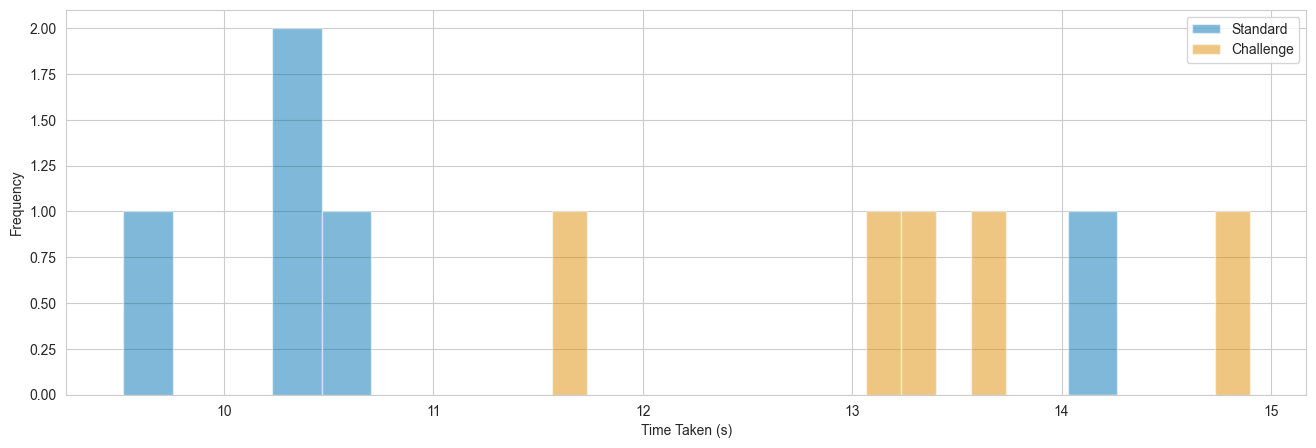

Time taken for standard is not normally distributed
Time taken for challenge is normally distributed


In [19]:
# Check for normality of time taken for standard and challenge
from scipy import stats
print(stats.shapiro(time_taken_standard))
print(stats.shapiro(time_taken_challenge))

# Plot the time taken for standard and challenge
plt.figure(figsize=(16, 5))
plt.hist(time_taken_standard, bins=20, alpha=0.5, label='Standard')
plt.hist(time_taken_challenge, bins=20, alpha=0.5, label='Challenge')
plt.xlabel('Time Taken (s)')
plt.ylabel('Frequency')

# Add a fit line for the standard and challenge
plt.legend()
plt.show()

# Conclusion
if stats.shapiro(time_taken_standard)[1] > 0.05:
    print("Time taken for standard is normally distributed")
else:
    print("Time taken for standard is not normally distributed")

if stats.shapiro(time_taken_challenge)[1] > 0.05:
    print("Time taken for challenge is normally distributed")


In [20]:
time_taken_standard = np.array(time_taken_standard)
time_taken_challenge = np.array(time_taken_challenge)

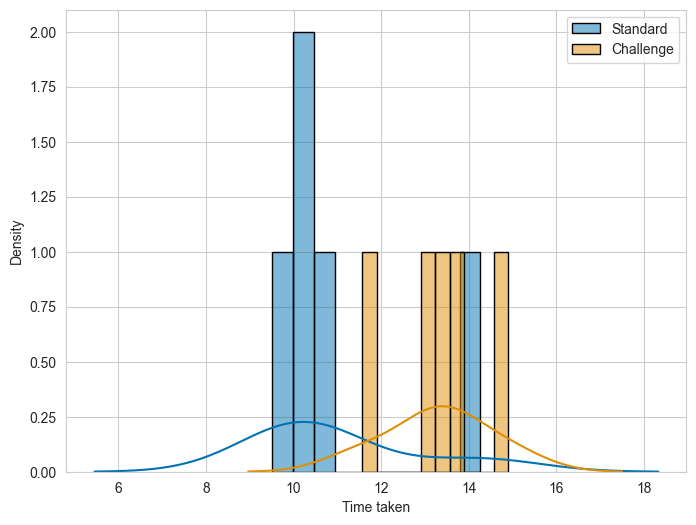

In [60]:
plt.figure(figsize=(8, 6))
sns.histplot(time_taken_standard, bins=10, alpha=0.5, label='Standard', edgecolor='black')
sns.histplot(time_taken_challenge, bins=10, alpha=0.5, label='Challenge', edgecolor='black')
# Plot a fit line
sns.kdeplot(time_taken_standard, )
sns.kdeplot(time_taken_challenge,)
# plt.title('Distribution of Time Taken for Standard and Challenge Sit to Stand tasks')
plt.xlabel('Time taken')
plt.ylabel('Density')
plt.legend()
plt.show()

Shapiro-Wilk test: p-value = 0.4261
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


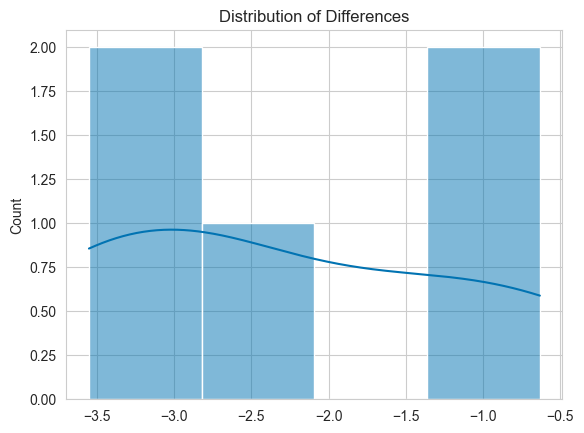

In [59]:
from scipy.stats import shapiro

diff = time_taken_standard - time_taken_challenge
stat, p = shapiro(diff)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(diff, kde=True)
plt.title("Distribution of Differences")
plt.show()


In [62]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(time_taken_standard, time_taken_challenge)
print(time_taken_challenge, time_taken_standard)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

if p_val <= 0.05:
    print("Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.")
else:
    print("Fail to reject H_0: no significant difference")

# One sided t-test
# Claim that performance decreases



[11.567 14.9   13.067 13.367 13.6  ] [10.25  14.267  9.517 10.567 10.45 ]
Paired t-test: t = -4.087, p = 0.0150
Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.
